In [ ]:
# ============================================================
# ONE CELL (colon): OPTUNA with GO-LR ONCE per trial
# Per trial:
#   1) GO-LR fit on FULL X -> Pi_star (fixed for all folds in that trial)
#   2) 5x5 CV folds:
#        NSC configure on train only (uses fixed Pi_star)
#        compress train/val
#        TabPFN fit on train, eval on val
# ============================================================

import os, sys, gc, random, warnings
warnings.filterwarnings("ignore")

os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")
os.environ.setdefault("CUDA_DEVICE_ORDER", "PCI_BUS_ID")

import optuna
import numpy as np
import pandas as pd
import torch

from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
from tqdm import tqdm

# ---- IMPORTANT: import from your single file ----
# Your gotabpfn.py defines:
#   GraphFeatureOrdering, pidf_segpca, TabPFN25Head, TabPFN25Config
from gotabpfn import GraphFeatureOrdering, pidf_segpca, TabPFN25Head, TabPFN25Config
PIDFSegPCA = pidf_segpca  # alias to match your earlier naming

# -----------------------
# Config
# -----------------------
SEED = 42
DATA_FILE  = "coloncancer_encoded.csv"
TARGET_COL = "label"

N_TRIALS = 150
GPU_ID = 7  # change if needed

# If you want to force which GPU is visible for kmeans_gpu + tabpfn:
if "torch" not in sys.modules:
    os.environ["CUDA_VISIBLE_DEVICES"] = str(GPU_ID)

# -----------------------
# Utils
# -----------------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def cleanup_cuda():
    gc.collect()
    if torch.cuda.is_available():
        try:
            torch.cuda.synchronize()
        except Exception:
            pass
        torch.cuda.empty_cache()

def ensure_multiclass_contiguous(y: np.ndarray):
    y = np.asarray(y).reshape(-1)
    uniq = np.unique(y)
    uniq_sorted = np.sort(uniq)
    class_map = {orig: i for i, orig in enumerate(uniq_sorted.tolist())}
    y_enc = np.vectorize(class_map.get, otypes=[np.int64])(y).astype(np.int64)
    return y_enc, class_map, int(len(class_map))

def compute_deltas_adjacent_corr(X_tr: np.ndarray, Pi_star: list[int], eps: float = 1e-12) -> torch.Tensor:
    """
    delta[t] = 1 - |corr(feature_{Pi[t]}, feature_{Pi[t+1]})|
    Returns torch.Tensor shape (m-1,) on CPU.
    """
    X = torch.from_numpy(X_tr).float()  # CPU
    perm = torch.tensor(Pi_star, dtype=torch.long)
    Xp = X[:, perm]
    Xc = Xp - Xp.mean(dim=0, keepdim=True)
    std = Xc.std(dim=0, unbiased=False, keepdim=True).clamp_min(eps)
    Z = Xc / std
    corr = (Z[:, :-1] * Z[:, 1:]).mean(dim=0)
    return (1.0 - corr.abs()).cpu()

# -----------------------
# Load data
# -----------------------
seed_everything(SEED)
df = pd.read_csv(DATA_FILE)

y_raw = df[TARGET_COL].to_numpy()
X_df  = df.drop(columns=[TARGET_COL])

y, class_map, NUM_CLASSES = ensure_multiclass_contiguous(y_raw)

# Standardize globally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df.values).astype(np.float32, copy=False)

X_all = np.asarray(X_scaled, dtype=np.float32, order="C")
y_all = np.asarray(y, dtype=np.int64)

print(f"[DATA] {DATA_FILE} | X={X_all.shape} | C={NUM_CLASSES} | map={class_map}")
print("[GPU ] cuda=", torch.cuda.is_available(), "| visible_gpus=", torch.cuda.device_count())

# 5x5 CV
rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED)

# Devices
NSC_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
TABPFN_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# -----------------------
# Optuna objective
# -----------------------
def objective(trial: optuna.Trial):
    seed_everything(SEED)

    # --------- Tune GO-LR (once per trial) ----------
    go_metric = trial.suggest_categorical(
        "go_metric", ["correlation", "cosine", "manhattan", "euclidean", "kl_divergence"]
    )
    go_k = trial.suggest_int("go_num_clusters", 4, 12)
    go_refine_passes = trial.suggest_int("go_refine_passes", 1, 3)
    go_direction = trial.suggest_categorical("go_direction_select", [True, False])

    # IMPORTANT: prefer GPU KMeans first; CPU only as fallback
    # So we DO NOT tune go_use_cpu_kmeans here.
    # We try use_cpu_kmeans=False first, then fallback True if needed.

    # --------- Tune NSC ----------
    nsc_seg = trial.suggest_categorical("nsc_segmentation", ["uniform", "largest_jump", "equal_mass"])
    nsc_m_rule = trial.suggest_categorical("nsc_m_rule", ["default", "idf", "gamma"])
    nsc_tau = trial.suggest_categorical("nsc_tau", [0.95, 0.99, 0.9975])
    nsc_gamma = trial.suggest_float("nsc_gamma", 1.0, 3.0)
    nsc_beta = trial.suggest_float("nsc_beta", 0.0, 0.9)
    nsc_Mmin = trial.suggest_categorical("nsc_Mmin", [16, 32, 48, 64])
    nsc_Mmax = trial.suggest_categorical("nsc_Mmax", [128, 256, 384, 512, 640])
    nsc_lmin = trial.suggest_categorical("nsc_lmin", [8, 12, 16])
    assume_standardized = trial.suggest_categorical("assume_standardized", [True, False])

    # TabPFN seed (head is frozen; but its internal rng can matter)
    tabpfn_seed = trial.suggest_categorical("tabpfn_seed", [0, 1, 2, 3, 4, 42])

    # ---- GO-LR ONCE per trial ----
    go = GraphFeatureOrdering(
        num_clusters=int(go_k),
        metric=go_metric,
        refine=True,
        direction_select=bool(go_direction),
        refine_passes=int(go_refine_passes),
    )

    try:
        # Prefer GPU kmeans
        Pi_star, _, _, _ = go.fit(X_all, seed=SEED, deterministic=True, use_cpu_kmeans=False)
    except RuntimeError as e:
        # Fallback to CPU kmeans if GPU path OOMs/fails
        cleanup_cuda()
        try:
            Pi_star, _, _, _ = go.fit(X_all, seed=SEED, deterministic=True, use_cpu_kmeans=True)
        except Exception:
            raise optuna.TrialPruned(f"GO-LR failed (metric={go_metric})")

    # ---- 5x5 CV: NSC+TabPFN per fold using fixed Pi_star ----
    head_cfg = TabPFN25Config(
        task_type="binary",
        num_classes=int(NUM_CLASSES),
        device=TABPFN_DEVICE,
        random_state=int(tabpfn_seed),
    )

    accs = []
    for fold_id, (tr_idx, va_idx) in enumerate(rkf.split(X_all, y_all), start=1):
        X_tr = X_all[tr_idx]
        y_tr = y_all[tr_idx]
        X_va = X_all[va_idx]
        y_va = y_all[va_idx]

        # NSC config on TRAIN only
        nsc = PIDFSegPCA(
            segmentation=nsc_seg,
            l_min=int(nsc_lmin),
            m_rule=nsc_m_rule,
            gamma=float(nsc_gamma),
            beta=float(nsc_beta),
            tau=float(nsc_tau),
            M_min=int(nsc_Mmin),
            M_max=int(nsc_Mmax),
            assume_standardized=bool(assume_standardized),
            device=NSC_DEVICE,
        )

        deltas = None if nsc_seg == "uniform" else compute_deltas_adjacent_corr(X_tr, Pi_star)

        X_tr_t = torch.from_numpy(X_tr)
        nsc.configure(Pi_star=Pi_star, X_train=X_tr_t, tau=float(nsc_tau), deltas=deltas)

        Z_tr = nsc.compress(X_tr_t, mode="flatten").cpu().numpy()
        Z_va = nsc.compress(torch.from_numpy(X_va), mode="flatten").cpu().numpy()

        # TabPFN fit/eval
        head = TabPFN25Head(head_cfg)
        head.fit(Z_tr, y_tr)

        P = head.predict_proba(Z_va)
        pred = np.argmax(P, axis=1)
        acc = float(accuracy_score(y_va, pred))
        accs.append(acc)

        # prune on running mean
        trial.report(float(np.mean(accs)), step=fold_id)
        if trial.should_prune():
            cleanup_cuda()
            raise optuna.TrialPruned()

        cleanup_cuda()

    mean_acc = float(np.mean(accs))
    std_acc  = float(np.std(accs, ddof=1))
    trial.set_user_attr("mean_acc", mean_acc)
    trial.set_user_attr("std_acc", std_acc)
    return mean_acc

# -----------------------
# Run Optuna
# -----------------------
sampler = optuna.samplers.TPESampler(seed=SEED, multivariate=True, group=True)
pruner  = optuna.pruners.MedianPruner(n_warmup_steps=10)  # warmup because 25 folds

study = optuna.create_study(direction="maximize", sampler=sampler, pruner=pruner)
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True, gc_after_trial=True, n_jobs=1)

best = study.best_trial
print("\n================ BEST TRIAL ================")
print(f"mean_acc ± std_acc = {best.user_attrs.get('mean_acc', best.value):.6f} ± {best.user_attrs.get('std_acc', float('nan')):.6f}")
print("\nBest hyperparameters:")
for k, v in best.params.items():
    print(f"  {k}: {v}")

[I 2026-01-27 11:57:19,907] A new study created in memory with name: no-name-7d40ca0a-22af-44dd-ad48-d18b74839337


[DATA] coloncancer_encoded.csv | X=(62, 2000) | C=2 | map={0: 0, 1: 1}
[GPU ] cuda= True | visible_gpus= 8


  0%|          | 0/150 [00:00<?, ?it/s]

[I 2026-01-27 11:57:52,372] Trial 0 finished with value: 0.8461538461538461 and parameters: {'go_metric': 'cosine', 'go_num_clusters': 5, 'go_refine_passes': 1, 'go_direction_select': True, 'nsc_segmentation': 'equal_mass', 'nsc_m_rule': 'default', 'nsc_tau': 0.9975, 'nsc_gamma': 1.8638900372842315, 'nsc_beta': 0.26210622617823776, 'nsc_Mmin': 16, 'nsc_Mmax': 256, 'nsc_lmin': 12, 'assume_standardized': False, 'tabpfn_seed': 0}. Best is trial 0 with value: 0.8461538461538461.
[I 2026-01-27 11:58:20,277] Trial 1 finished with value: 0.8358974358974359 and parameters: {'go_metric': 'euclidean', 'go_num_clusters': 9, 'go_refine_passes': 1, 'go_direction_select': False, 'nsc_segmentation': 'largest_jump', 'nsc_m_rule': 'default', 'nsc_tau': 0.95, 'nsc_gamma': 1.0904545778210761, 'nsc_beta': 0.2927972976869379, 'nsc_Mmin': 48, 'nsc_Mmax': 512, 'nsc_lmin': 8, 'assume_standardized': False, 'tabpfn_seed': 2}. Best is trial 0 with value: 0.8461538461538461.
[I 2026-01-27 11:58:49,203] Trial 2 fi

# Inference Level Diagnostics: Robustness + Calibration

[BEST] mean_acc = 0.8817948717948718 std_acc = 0.10054230554800825
[BEST] params: {'go_metric': 'euclidean', 'go_num_clusters': 10, 'go_refine_passes': 3, 'go_direction_select': True, 'nsc_segmentation': 'equal_mass', 'nsc_m_rule': 'idf', 'nsc_tau': 0.99, 'nsc_gamma': 1.7570143129240916, 'nsc_beta': 0.2244046472232107, 'nsc_Mmin': 64, 'nsc_Mmax': 384, 'nsc_lmin': 16, 'assume_standardized': False, 'tabpfn_seed': 42}
[INFO] Pi* length: 2000
[INFO] NSC latent shape: (62, 70)
[INFO] GOTabPFN head trained on full Colon dataset (seed=42, device=cuda)


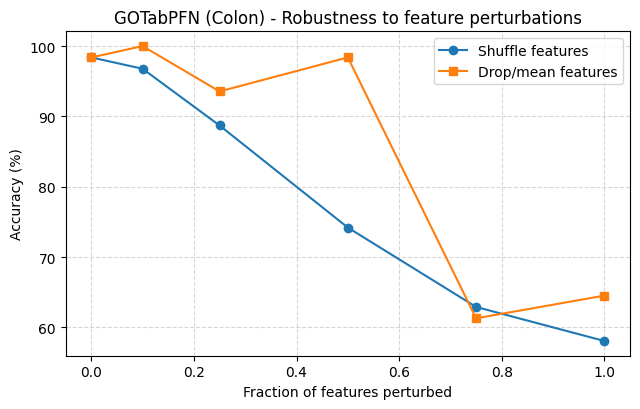

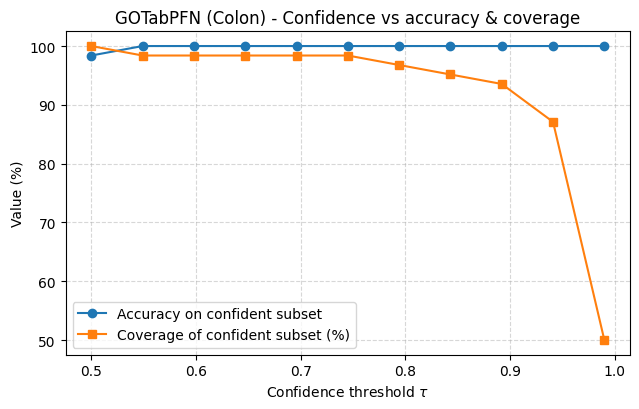

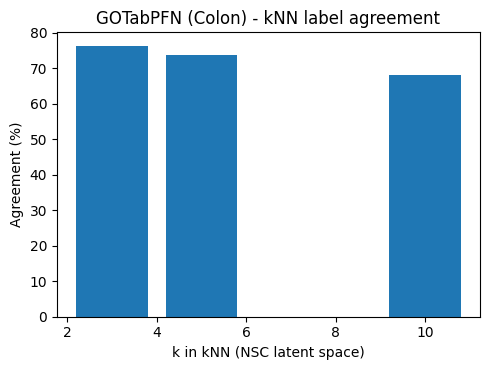

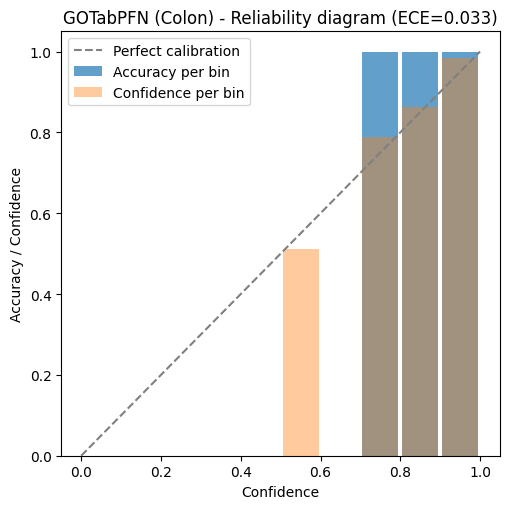


=== GOTabPFN Inference Ablation Summary (Colon) ===
      Tab Shuffle ↓  Tab Drop ↓  kNN-Agree@5 (%)
0.00          98.39       98.39            73.87
0.10          96.77      100.00            73.87
0.25          88.71       93.55            73.87
0.50          74.19       98.39            73.87
0.75          62.90       61.29            73.87
1.00          58.06       64.52            73.87

Expected Calibration Error (ECE): 0.033


In [ ]:
# ============================================================
# Inference-level diagnostics for GOTabPFN on Colon
#  - Robustness to feature perturbations (in original feature space)
#  - Confidence vs accuracy/coverage
#  - kNN consistency in NSC latent space
#  - Calibration (reliability diagram + ECE)
# ============================================================
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import StandardScaler
import pandas as pd

plt.rcParams.update({
    "savefig.facecolor": "white",
    "figure.facecolor": "white"
})

# ------------------------------------------------
# 0) Rebuild best GO-LR + NSC + TabPFN head
# ------------------------------------------------
best = study.best_trial
p = best.params
print("[BEST] mean_acc =", best.user_attrs.get("mean_acc", best.value),
      "std_acc =", best.user_attrs.get("std_acc", float("nan")))
print("[BEST] params:", p)

# --- GO-LR with best params ---
go_best = GraphFeatureOrdering(
    num_clusters=int(p["go_num_clusters"]),
    metric=p["go_metric"],
    refine=True,
    direction_select=bool(p["go_direction_select"]),
    refine_passes=int(p["go_refine_passes"]),
)

try:
    Pi_star_best, _, _, _ = go_best.fit(
        X_all,
        seed=SEED,
        deterministic=True,
        use_cpu_kmeans=False,  # GPU first
    )
except RuntimeError:
    cleanup_cuda()
    Pi_star_best, _, _, _ = go_best.fit(
        X_all,
        seed=SEED,
        deterministic=True,
        use_cpu_kmeans=True,   # CPU fallback
    )

print("[INFO] Pi* length:", len(Pi_star_best))

# --- NSC (PIDFSegPCA) with best params ---
nsc_best = PIDFSegPCA(
    segmentation=p["nsc_segmentation"],
    l_min=int(p["nsc_lmin"]),
    m_rule=p["nsc_m_rule"],
    gamma=float(p["nsc_gamma"]),
    beta=float(p["nsc_beta"]),
    tau=float(p["nsc_tau"]),
    M_min=int(p["nsc_Mmin"]),
    M_max=int(p["nsc_Mmax"]),
    assume_standardized=bool(p["assume_standardized"]),
    device=NSC_DEVICE,
)

deltas_best = None
if p["nsc_segmentation"] != "uniform":
    deltas_best = compute_deltas_adjacent_corr(X_all, Pi_star_best)

X_all_torch = torch.from_numpy(X_all)
nsc_best.configure(
    Pi_star=Pi_star_best,
    X_train=X_all_torch,
    tau=float(p["nsc_tau"]),
    deltas=deltas_best,
)

Z_all = nsc_best.compress(X_all_torch, mode="flatten").cpu().numpy()
print("[INFO] NSC latent shape:", Z_all.shape)

# standardize latent for kNN / t-SNE style geometry
Z_all_std = StandardScaler().fit_transform(Z_all)

# --- TabPFN head trained on full Colon latent space ---
tabpfn_seed_best = int(p["tabpfn_seed"])
head_cfg_best = TabPFN25Config(
    task_type="binary",
    num_classes=int(NUM_CLASSES),
    device=TABPFN_DEVICE,
    random_state=tabpfn_seed_best,
)

head_best = TabPFN25Head(head_cfg_best)
head_best.fit(Z_all, y_all)

print("[INFO] GOTabPFN head trained on full Colon dataset "
      f"(seed={tabpfn_seed_best}, device={TABPFN_DEVICE})")


# ------------------------------------------------
# Helper: forward through GOTabPFN (NSC + TabPFN head)
# ------------------------------------------------
def gotabpfn_predict_on_X(X_np: np.ndarray):
    """
    X_np: (N, m) numpy array in original feature space (standardized Colon).
    Returns:
        probs: (N, C)
        preds: (N,)
        y:     (N,)   (here we just re-use y_all externally)
        embs:  (N, d) NSC latent (standardized) used as embedding space
    """
    X_t = torch.from_numpy(X_np.astype(np.float32, copy=False))
    Z = nsc_best.compress(X_t, mode="flatten").cpu().numpy()   # (N, d)
    probs = head_best.predict_proba(Z)                         # (N, C)
    preds = np.argmax(probs, axis=1)
    # use standardized NSC latent as embedding
    Z_std = StandardScaler().fit_transform(Z)
    return probs, preds, Z_std


# ------------------------------------------------
# 1) Robustness to feature perturbations (Colon)
# ------------------------------------------------
np.random.seed(SEED)

def make_feature_shuffle_perturber_X(p):
    """
    Randomly permute a fraction p of feature columns across the batch (in X-space).
    """
    def _perturb(X):
        X = X.copy()
        N, m = X.shape
        k = int(round(p * m))
        if k > 0:
            cols = np.random.choice(m, size=k, replace=False)
            for c in cols:
                perm = np.random.permutation(N)
                X[:, c] = X[perm, c]
        return X
    return _perturb


def make_feature_drop_perturber_X(p):
    """
    Replace a fraction p of feature columns with their global mean (in X-space).
    """
    def _perturb(X):
        X = X.copy()
        N, m = X.shape
        k = int(round(p * m))
        if k > 0:
            cols = np.random.choice(m, size=k, replace=False)
            col_means = X.mean(axis=0, keepdims=True)
            X[:, cols] = col_means[:, cols]
        return X
    return _perturb


def eval_accuracy_on_X(X_base, y_base, perturb=None):
    if perturb is not None:
        X_in = perturb(X_base)
    else:
        X_in = X_base
    probs, preds, _ = gotabpfn_predict_on_X(X_in)
    return accuracy_score(y_base, preds) * 100.0


ps = [0.0, 0.1, 0.25, 0.5, 0.75, 1.0]
acc_shuffle = [
    eval_accuracy_on_X(X_all, y_all, make_feature_shuffle_perturber_X(p)) for p in ps
]
acc_drop = [
    eval_accuracy_on_X(X_all, y_all, make_feature_drop_perturber_X(p)) for p in ps
]

plt.figure(figsize=(6.5, 4.2))
plt.plot(ps, acc_shuffle, '-o', label='Shuffle features')
plt.plot(ps, acc_drop,    '-s', label='Drop/mean features')
plt.xlabel("Fraction of features perturbed")
plt.ylabel("Accuracy (%)")
plt.title("GOTabPFN (Colon) - Robustness to feature perturbations")
plt.grid(True, ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("gotabpfn_colon_robustness.png", dpi=600, bbox_inches='tight')
plt.savefig("gotabpfn_colon_robustness.pdf", dpi=600, bbox_inches='tight')
plt.show()


# ------------------------------------------------
# 2) Confidence vs accuracy / coverage + kNN agreement
# ------------------------------------------------
probs_full, preds_full, embs_full = gotabpfn_predict_on_X(X_all)
y_full = y_all.copy()

conf = probs_full.max(axis=1)

taus = np.linspace(0.5, 0.99, 11)
idx_conf   = [np.where(conf >= t)[0] for t in taus]
acc_conf   = [
    accuracy_score(y_full[idx], preds_full[idx]) * 100.0 if len(idx) > 0 else np.nan
    for idx in idx_conf
]
ratio_conf = [len(idx) / len(y_full) * 100.0 for idx in idx_conf]

# kNN agreement in NSC latent space
nbrs = NearestNeighbors(n_neighbors=11, metric="euclidean").fit(embs_full)
neigh = nbrs.kneighbors(embs_full, return_distance=False)[:, 1:]  # exclude self

agree = []
for k in [3, 5, 10]:
    a = [(preds_full[neigh[i, :k]] == preds_full[i]).mean() for i in range(len(y_full))]
    agree.append(100.0 * np.mean(a))

plt.figure(figsize=(6.5, 4.2))
plt.plot(taus, acc_conf,   '-o', label='Accuracy on confident subset')
plt.plot(taus, ratio_conf, '-s', label='Coverage of confident subset (%)')
plt.xlabel("Confidence threshold $\\tau$")
plt.ylabel("Value (%)")
plt.title("GOTabPFN (Colon) - Confidence vs accuracy & coverage")
plt.grid(True, ls='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("gotabpfn_colon_confidence_curve.png", dpi=600, bbox_inches='tight')
plt.savefig("gotabpfn_colon_confidence_curve.pdf", dpi=600, bbox_inches='tight')
plt.show()

plt.figure(figsize=(5.0, 3.8))
plt.bar([3, 5, 10], agree, width=1.6)
plt.xlabel("k in kNN (NSC latent space)")
plt.ylabel("Agreement (%)")
plt.title("GOTabPFN (Colon) - kNN label agreement")
plt.tight_layout()
plt.savefig("gotabpfn_colon_knn_agreement.png", dpi=600, bbox_inches='tight')
plt.savefig("gotabpfn_colon_knn_agreement.pdf", dpi=600, bbox_inches='tight')
plt.show()


# ------------------------------------------------
# 3) Calibration: reliability diagram + ECE
# ------------------------------------------------
bins    = np.linspace(0.0, 1.0, 11)
bin_ids = np.digitize(conf, bins) - 1

acc_bin, conf_bin, cnt_bin = [], [], []
for b in range(len(bins) - 1):
    idx = np.where(bin_ids == b)[0]
    if len(idx) == 0:
        acc_bin.append(0.0)
        conf_bin.append(0.0)
        cnt_bin.append(0)
    else:
        acc_bin.append(accuracy_score(y_full[idx], preds_full[idx]))
        conf_bin.append(conf[idx].mean())
        cnt_bin.append(len(idx))

acc_bin  = np.array(acc_bin)
conf_bin = np.array(conf_bin)
cnt_bin  = np.array(cnt_bin)

ece = np.sum(np.abs(acc_bin - conf_bin) * (cnt_bin / len(y_full)))

plt.figure(figsize=(5.2, 5.2))
plt.plot([0, 1], [0, 1], '--', color='gray', label='Perfect calibration')
plt.bar(bins[:-1] + 0.05, acc_bin,  width=0.09, alpha=0.7, label='Accuracy per bin')
plt.bar(bins[:-1] + 0.05, conf_bin, width=0.09, alpha=0.4, label='Confidence per bin')
plt.xlabel("Confidence")
plt.ylabel("Accuracy / Confidence")
plt.title(f"GOTabPFN (Colon) - Reliability diagram (ECE={ece:.3f})")
plt.legend()
plt.tight_layout()
plt.savefig("gotabpfn_colon_reliability.png", dpi=600, bbox_inches='tight')
plt.savefig("gotabpfn_colon_reliability.pdf", dpi=600, bbox_inches='tight')
plt.show()


# ------------------------------------------------
# 4) Summary table
# ------------------------------------------------
df_summary = pd.DataFrame({
    "Tab Shuffle ↓": acc_shuffle,
    "Tab Drop ↓":    acc_drop,
}, index=[f"{p:.2f}" for p in ps])

df_summary["kNN-Agree@5 (%)"] = agree[1]

print("\n=== GOTabPFN Inference Ablation Summary (Colon) ===")
print(df_summary.round(2))
print(f"\nExpected Calibration Error (ECE): {ece:.3f}")

# Sanity and Stress Diagnostics

[INFO] Extra sanity & stress tests using GOTabPFN on Colon

[Mode: full]
  Accuracy =  98.39 %  (n=62)

[Mode: zero]
  Accuracy =  64.52 %  (n=62)

[Mode: mean]
  Accuracy =  64.52 %  (n=62)

[Mode: shuffle_rows]
  Accuracy =  54.84 %  (n=62)

[Mode: heavy_noise]
  Accuracy =  95.16 %  (n=62)


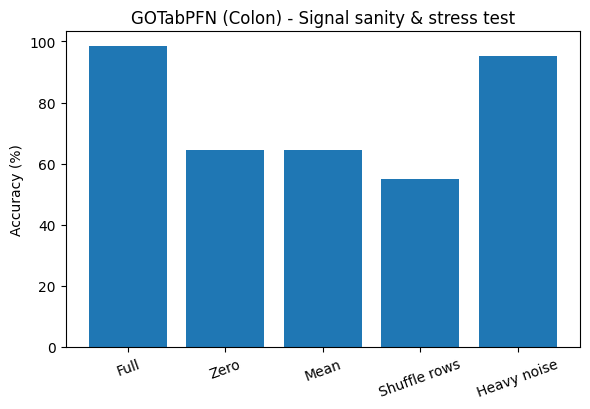


=== Augmentation consistency / stress (GOTabPFN, Colon) ===
Base accuracy:  98.39 %
TTA majority-vote accuracy (n_aug=5):  98.39 %
Fraction of samples with any label change across aug:   3.23 %


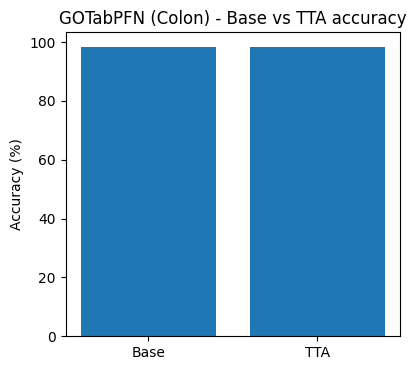


=== Per-class accuracy summary (GOTabPFN, Colon, sorted by support) ===
   class_id  support  accuracy
0         0       40      97.5
1         1       22     100.0

=== Bucketed per-class accuracy (GOTabPFN, by support) ===
        count   mean
bucket              
head        1   97.5
tail        1  100.0


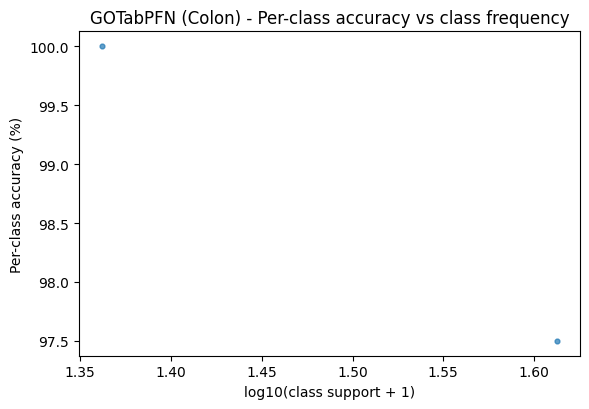


[Done] GOTabPFN extra sanity & stress tests (Colon) complete.
Saved figures:
  - gotabpfn_colon_signal_sanity_stress.(png|pdf)
  - gotabpfn_colon_tta_accuracy.(png|pdf)
  - gotabpfn_colon_per_class_accuracy.(png|pdf)


In [ ]:
# ============================================================
# Extra sanity & stress diagnostics for GOTabPFN (Colon)
#   1) Signal sanity / stress modes (full vs degenerate inputs)
#   2) Augmentation consistency / TTA stress test
#   3) Per-class accuracy vs class frequency
# Requires:
#   - X_all, y_all (Colon dataset)
#   - gotabpfn_predict_on_X(X_np) from previous GOTabPFN cell
# ============================================================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import accuracy_score
from collections import Counter

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})

# Sanity: check helper exists
try:
    gotabpfn_predict_on_X
except NameError as e:
    raise RuntimeError(
        "gotabpfn_predict_on_X is not defined. "
        "Run the previous GOTabPFN diagnostics cell first."
    ) from e

print("[INFO] Extra sanity & stress tests using GOTabPFN on Colon")


# -------------------------------------------------------------------
# 1. Signal sanity & stress tests (in original X-space)
#    Modes:
#      - full        : original inputs
#      - zero        : all features zero (should go near chance)
#      - mean        : all features set to global mean
#      - shuffle_rows: permute rows (break X–y alignment)
#      - heavy_noise : add strong Gaussian noise
# -------------------------------------------------------------------
def make_signal_perturber_X(mode, X_stats=None):
    """
    mode ∈ {"full", "zero", "mean", "shuffle_rows", "heavy_noise"}.
    X_stats: optional dict with {"mean": np.ndarray} computed once.
    """
    assert mode in {"full", "zero", "mean", "shuffle_rows", "heavy_noise"}

    def _perturb(X):
        X = np.asarray(X, dtype=np.float32)
        N, m = X.shape

        if mode == "full":
            return X

        if mode == "zero":
            return np.zeros_like(X, dtype=np.float32)

        if mode == "mean":
            if X_stats is None or "mean" not in X_stats:
                raise ValueError("X_stats['mean'] required for 'mean' mode.")
            mean_vec = X_stats["mean"]  # shape (1, m)
            return np.repeat(mean_vec, N, axis=0)

        if mode == "shuffle_rows":
            perm = np.random.permutation(N)
            return X[perm]

        if mode == "heavy_noise":
            # Strong Gaussian noise relative to feature scale
            noise = np.random.randn(*X.shape).astype(np.float32) * 0.5
            return X + noise

        return X

    return _perturb


# Compute global mean on full Colon (for "mean" mode)
X_mean_np = X_all.mean(axis=0, keepdims=True)  # (1, m)
X_stats = {"mean": X_mean_np}


def eval_signal_modes_X(X, y, modes, X_stats):
    results = {}
    for m in modes:
        print(f"\n[Mode: {m}]")
        perturb = make_signal_perturber_X(m, X_stats)
        X_p = perturb(X)
        probs, preds, _ = gotabpfn_predict_on_X(X_p)
        acc = accuracy_score(y, preds) * 100.0
        results[m] = acc
        print(f"  Accuracy = {acc:6.2f} %  (n={len(y)})")
    return results


modes = ["full", "zero", "mean", "shuffle_rows", "heavy_noise"]
signal_results = eval_signal_modes_X(X_all, y_all, modes, X_stats)

# Plot as bar chart
plt.figure(figsize=(6.0, 4.2))
names = ["Full", "Zero", "Mean", "Shuffle rows", "Heavy noise"]
vals  = [signal_results[m] for m in modes]
plt.bar(range(len(names)), vals)
plt.xticks(range(len(names)), names, rotation=20)
plt.ylabel("Accuracy (%)")
plt.title("GOTabPFN (Colon) - Signal sanity & stress test")
plt.tight_layout()
plt.savefig("gotabpfn_colon_signal_sanity_stress.png", dpi=600, bbox_inches="tight")
plt.savefig("gotabpfn_colon_signal_sanity_stress.pdf", dpi=600, bbox_inches="tight")
plt.show()


# -------------------------------------------------------------------
# 2. Augmentation consistency / stress test (tabular TTA)
#    - Augment = mild noise + random feature dropout
#    - Compare base vs TTA majority-vote accuracy
#    - Measure fraction of samples whose prediction changes under aug
# -------------------------------------------------------------------
def random_tabular_augment_X(X, noise_std=0.05, drop_prob=0.1):
    """
    Simple tabular augmentation:
      - Add Gaussian noise with std=noise_std
      - Randomly zero out each feature with probability drop_prob
    """
    X = np.asarray(X, dtype=np.float32).copy()
    # Gaussian noise
    noise = np.random.randn(*X.shape).astype(np.float32) * noise_std
    X = X + noise

    if drop_prob > 0.0:
        mask = (np.random.rand(*X.shape) > drop_prob).astype(np.float32)
        X = X * mask

    return X


def predict_with_tab_aug_gotabpfn(X, y, n_aug=5, noise_std=0.05, drop_prob=0.1):
    # Base predictions
    probs_base, preds_base, _ = gotabpfn_predict_on_X(X)
    base_acc = accuracy_score(y, preds_base) * 100.0

    # Augmented predictions
    all_aug_preds = []

    for j in range(n_aug):
        X_aug = random_tabular_augment_X(X, noise_std=noise_std, drop_prob=drop_prob)
        _, preds_aug, _ = gotabpfn_predict_on_X(X_aug)
        all_aug_preds.append(preds_aug)

    all_aug_preds = np.stack(all_aug_preds, axis=1)  # [N, n_aug]

    # Majority vote across augmentations
    maj_preds = []
    for i in range(all_aug_preds.shape[0]):
        vals, counts = np.unique(all_aug_preds[i], return_counts=True)
        maj_preds.append(vals[counts.argmax()])
    maj_preds = np.array(maj_preds)

    # Metrics
    tta_acc      = accuracy_score(y, maj_preds) * 100.0
    change_mask  = (all_aug_preds != preds_base[:, None]).any(axis=1)
    frac_changed = change_mask.mean() * 100.0

    print("\n=== Augmentation consistency / stress (GOTabPFN, Colon) ===")
    print(f"Base accuracy: {base_acc:6.2f} %")
    print(f"TTA majority-vote accuracy (n_aug={n_aug}): {tta_acc:6.2f} %")
    print(f"Fraction of samples with any label change across aug: {frac_changed:6.2f} %")

    return {
        "base_acc": base_acc,
        "tta_acc": tta_acc,
        "frac_changed": frac_changed,
        "y": y,
        "preds_base": preds_base,
        "maj_preds": maj_preds,
        "all_aug_preds": all_aug_preds,
    }


aug_results = predict_with_tab_aug_gotabpfn(
    X_all,
    y_all,
    n_aug=5,
    noise_std=0.05,
    drop_prob=0.1,
)

# Base vs TTA accuracy plot
plt.figure(figsize=(4.2, 3.8))
plt.bar([0, 1], [aug_results["base_acc"], aug_results["tta_acc"]])
plt.xticks([0, 1], ["Base", "TTA"])
plt.ylabel("Accuracy (%)")
plt.title("GOTabPFN (Colon) - Base vs TTA accuracy")
plt.tight_layout()
plt.savefig("gotabpfn_colon_tta_accuracy.png", dpi=600, bbox_inches="tight")
plt.savefig("gotabpfn_colon_tta_accuracy.pdf", dpi=600, bbox_inches="tight")
plt.show()


# -------------------------------------------------------------------
# 3. Per-class accuracy vs class frequency
# -------------------------------------------------------------------
probs_full, preds_full, _ = gotabpfn_predict_on_X(X_all)
labels = y_all
preds  = preds_full

classes = np.unique(labels)
per_class_acc = []
per_class_cnt = []

for c in classes:
    idx = np.where(labels == c)[0]
    per_class_cnt.append(len(idx))
    if len(idx) > 0:
        per_class_acc.append(accuracy_score(labels[idx], preds[idx]) * 100.0)
    else:
        per_class_acc.append(np.nan)

per_class_acc = np.array(per_class_acc)
per_class_cnt = np.array(per_class_cnt)

df_pc = pd.DataFrame({
    "class_id": classes,
    "support": per_class_cnt,
    "accuracy": per_class_acc,
})
df_pc = df_pc.sort_values("support", ascending=False)

print("\n=== Per-class accuracy summary (GOTabPFN, Colon, sorted by support) ===")
print(df_pc.round(2))

# Bucket head/medium/tail by support quantiles
quantiles = df_pc["support"].quantile([0.33, 0.67]).values
q1, q2 = quantiles[0], quantiles[1]

def _bucket(s):
    if s >= q2: return "head"
    if s >= q1: return "medium"
    return "tail"

df_pc["bucket"] = df_pc["support"].apply(_bucket)
bucket_summary = df_pc.groupby("bucket")["accuracy"].agg(["count", "mean"])

print("\n=== Bucketed per-class accuracy (GOTabPFN, by support) ===")
print(bucket_summary.round(2))

# Scatter: log10 support vs accuracy
plt.figure(figsize=(6.0, 4.2))
x_sc = np.log10(df_pc["support"] + 1)
y_sc = df_pc["accuracy"]
plt.scatter(x_sc, y_sc, s=12, alpha=0.7)
plt.xlabel("log10(class support + 1)")
plt.ylabel("Per-class accuracy (%)")
plt.title("GOTabPFN (Colon) - Per-class accuracy vs class frequency")
plt.tight_layout()
plt.savefig("gotabpfn_colon_per_class_accuracy.png", dpi=600, bbox_inches="tight")
plt.savefig("gotabpfn_colon_per_class_accuracy.pdf", dpi=600, bbox_inches="tight")
plt.show()

print("\n[Done] GOTabPFN extra sanity & stress tests (Colon) complete.")
print("Saved figures:")
print("  - gotabpfn_colon_signal_sanity_stress.(png|pdf)")
print("  - gotabpfn_colon_tta_accuracy.(png|pdf)")
print("  - gotabpfn_colon_per_class_accuracy.(png|pdf)")

# Additional Reliability and Interpretibility Diagnostics

[INFO] Running extra reliability diagnostics for GOTabPFN on Colon
[INFO] X_eval shape: (62, 2000), y_eval shape: (62,)
[INFO] Base accuracy on Colon (full set): 98.39% (N=62)


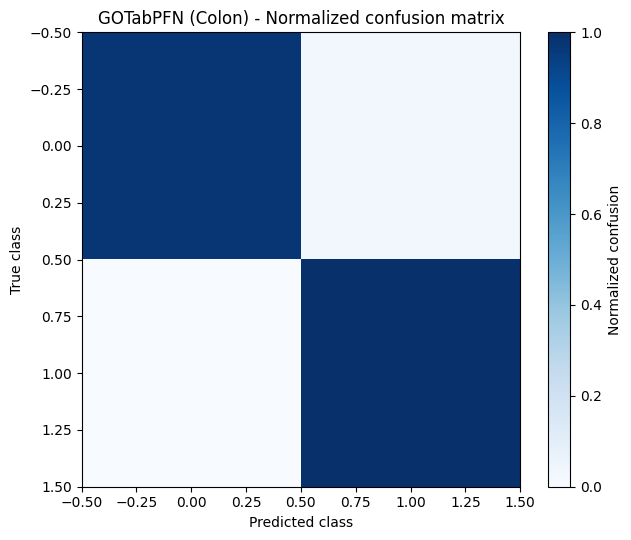


=== GOTabPFN (Colon): Top-10 most frequent confusions (true → predicted) ===
 1. true=0 → pred=1 | count=1

=== GOTabPFN (Colon): Top-k accuracies (manual) ===
Top-1 accuracy: 98.39%
Top-2 accuracy: 100.00%


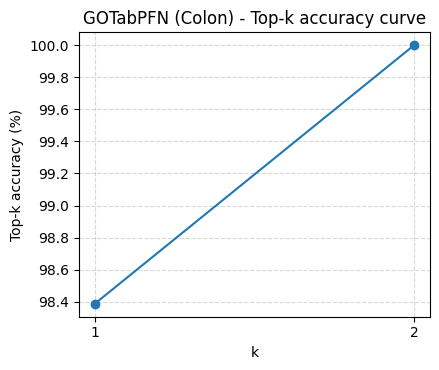


=== GOTabPFN (Colon): Margin statistics ===
Mean margin (correct): 0.949
Mean margin (wrong)  : 0.025


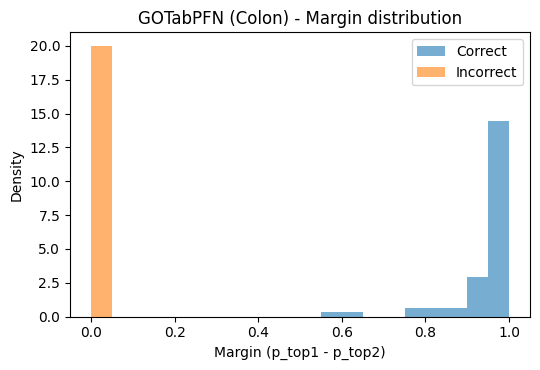


Detected tabular features: m = 2000
Baseline accuracy (again): 98.39%

=== GOTabPFN (Colon): Per-feature permutation importance ===

Top-15 most important features (by accuracy drop, percentage points):
       idx  acc_drop  feat
1996  1996       0.0  1997
0        0       0.0     1
1994  1994       0.0  1995
1988  1988       0.0  1989
3        3       0.0     4
1941  1941       0.0  1942
1943  1943       0.0  1944
1944  1944       0.0  1945
1947  1947       0.0  1948
1948  1948       0.0  1949
1934  1934       0.0  1935
1937  1937       0.0  1938
1938  1938       0.0  1939
1939  1939       0.0  1940
1929  1929       0.0  1930


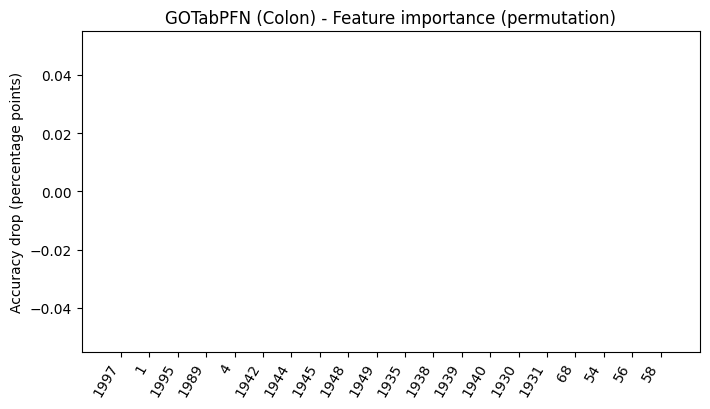


[Done] GOTabPFN (Colon) extra reliability diagnostics complete.
Saved figures:
  - gotabpfn_colon_confusion_matrix_norm.(png|pdf)
  - gotabpfn_colon_topk_accuracy.(png|pdf)
  - gotabpfn_colon_margin_hist.(png|pdf)
  - gotabpfn_colon_feature_importance_perm.(png|pdf)


In [ ]:
# ===================== Extra diagnostics pack (GOTabPFN, Colon) =====================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import (
    confusion_matrix,
    accuracy_score,
)

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})

# -------------------------------------------------------------------
# 0. Sanity: check helper + data
# -------------------------------------------------------------------
try:
    gotabpfn_predict_on_X
except NameError as e:
    raise RuntimeError(
        "gotabpfn_predict_on_X is not defined. "
        "Run the previous GOTabPFN cell where this helper is created."
    ) from e

try:
    X_all, y_all
except NameError as e:
    raise RuntimeError(
        "X_all / y_all not found. Make sure the Colon data is loaded as X_all, y_all."
    ) from e

X_eval = np.asarray(X_all, dtype=np.float32)
y_eval = np.asarray(y_all, dtype=int)

print("[INFO] Running extra reliability diagnostics for GOTabPFN on Colon")
print(f"[INFO] X_eval shape: {X_eval.shape}, y_eval shape: {y_eval.shape}")

# -------------------------------------------------------------------
# Helper: manual top-k accuracy (works for binary/multiclass)
# -------------------------------------------------------------------
def topk_accuracy_manual(y_true, probs, k, classes=None):
    """
    y_true : (N,) with original class labels
    probs  : (N, C) with probability per column class
    k      : int, top-k
    classes: array-like of class labels corresponding to columns of probs
             If None, assumes classes = [0, 1, ..., C-1]
    Returns accuracy (%) as float.
    """
    probs = np.asarray(probs)
    y_true = np.asarray(y_true)

    N, C = probs.shape
    if classes is None:
        classes = np.arange(C)
    classes = np.asarray(classes)

    # map y_true -> index in [0..C-1]
    class_to_idx = {c: i for i, c in enumerate(classes)}
    y_idx = np.vectorize(class_to_idx.get)(y_true)

    # sort probs descending and take top-k indices
    order = np.argsort(probs, axis=1)[:, ::-1]
    topk = order[:, :min(k, C)]   # safe if k > C

    # check if true index is in top-k for each sample
    correct = np.any(topk == y_idx[:, None], axis=1)
    return correct.mean() * 100.0

# -------------------------------------------------------------------
# 1. Base forward pass
# -------------------------------------------------------------------
probs, preds, Z_emb = gotabpfn_predict_on_X(X_eval)
classes = np.unique(y_eval)
num_classes = len(classes)
base_acc = accuracy_score(y_eval, preds) * 100.0
print(f"[INFO] Base accuracy on Colon (full set): {base_acc:.2f}% (N={len(y_eval)})")

# -------------------------------------------------------------------
# 2. Confusion matrix + normalized confusion
# -------------------------------------------------------------------
cm = confusion_matrix(y_eval, preds, labels=classes)
with np.errstate(divide="ignore", invalid="ignore"):
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    cm_norm[np.isnan(cm_norm)] = 0.0

plt.figure(figsize=(6.5, 5.5))
plt.imshow(cm_norm, interpolation="nearest", aspect="auto", cmap="Blues")
plt.colorbar(label="Normalized confusion")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.title("GOTabPFN (Colon) - Normalized confusion matrix")
plt.tight_layout()
plt.savefig("gotabpfn_colon_confusion_matrix_norm.png", dpi=600, bbox_inches="tight")
plt.savefig("gotabpfn_colon_confusion_matrix_norm.pdf", dpi=600, bbox_inches="tight")
plt.show()

# Top-10 confusion pairs
conf_pairs = []
for i_idx, i in enumerate(classes):
    for j_idx, j in enumerate(classes):
        if i == j:
            continue
        if cm[i_idx, j_idx] > 0:
            conf_pairs.append((cm[i_idx, j_idx], int(i), int(j)))
conf_pairs.sort(reverse=True)

print("\n=== GOTabPFN (Colon): Top-10 most frequent confusions (true → predicted) ===")
for k, (c, i, j) in enumerate(conf_pairs[:10], start=1):
    print(f"{k:2d}. true={i} → pred={j} | count={c}")

# -------------------------------------------------------------------
# 3. Top-k accuracy curve (k = 1..5, clipped by num_classes)
# -------------------------------------------------------------------
if num_classes == 1:
    ks = [1]
else:
    ks = [k for k in [1, 2, 3, 5] if k <= num_classes]

topk_accs = []
print("\n=== GOTabPFN (Colon): Top-k accuracies (manual) ===")
for k in ks:
    acc_k = topk_accuracy_manual(y_eval, probs, k=k, classes=classes)
    topk_accs.append(acc_k)
    print(f"Top-{k} accuracy: {acc_k:.2f}%")

plt.figure(figsize=(4.5, 3.8))
plt.plot(ks, topk_accs, "-o")
plt.xticks(ks)
plt.xlabel("k")
plt.ylabel("Top-k accuracy (%)")
plt.title("GOTabPFN (Colon) - Top-k accuracy curve")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("gotabpfn_colon_topk_accuracy.png", dpi=600, bbox_inches="tight")
plt.savefig("gotabpfn_colon_topk_accuracy.pdf", dpi=600, bbox_inches="tight")
plt.show()

# -------------------------------------------------------------------
# 4. Margin / confidence separation
#    margin = p_top1 - p_top2; compare distribution for correct vs wrong
# -------------------------------------------------------------------
sorted_probs = np.sort(probs, axis=1)[:, ::-1]
top1 = sorted_probs[:, 0]
top2 = sorted_probs[:, 1] if sorted_probs.shape[1] > 1 else np.zeros_like(top1)
margins = top1 - top2

correct = (preds == y_eval)
margins_correct = margins[correct]
margins_wrong   = margins[~correct]

print("\n=== GOTabPFN (Colon): Margin statistics ===")
print(f"Mean margin (correct): {margins_correct.mean():.3f}")
print(f"Mean margin (wrong)  : {margins_wrong.mean():.3f}")

plt.figure(figsize=(5.5, 3.8))
bins = np.linspace(0.0, 1.0, 21)
plt.hist(margins_correct, bins=bins, alpha=0.6, label="Correct",   density=True)
plt.hist(margins_wrong,   bins=bins, alpha=0.6, label="Incorrect", density=True)
plt.xlabel("Margin (p_top1 - p_top2)")
plt.ylabel("Density")
plt.title("GOTabPFN (Colon) - Margin distribution")
plt.legend()
plt.tight_layout()
plt.savefig("gotabpfn_colon_margin_hist.png", dpi=600, bbox_inches="tight")
plt.savefig("gotabpfn_colon_margin_hist.pdf", dpi=600, bbox_inches="tight")
plt.show()

# -------------------------------------------------------------------
# 5. Per-feature permutation importance (tabular accuracy drop)
#    - accuracy drop when shuffling ONE feature column across samples
# -------------------------------------------------------------------
N, m_features = X_eval.shape
print(f"\nDetected tabular features: m = {m_features}")
print(f"Baseline accuracy (again): {base_acc:.2f}%")

# get feature names from original Colon dataframe if present
feature_names = None
if "X_df" in globals():
    try:
        if hasattr(X_df, "columns"):
            if len(X_df.columns) == m_features:
                feature_names = list(X_df.columns)
            else:
                print("[WARN] X_df.columns length != m_features; using generic names.")
    except Exception:
        feature_names = None

def permute_single_feature(X, feat_idx):
    X_pert = X.copy()
    perm = np.random.permutation(X_pert.shape[0])
    X_pert[:, feat_idx] = X_pert[perm, feat_idx]
    return X_pert

drops = []
print("\n=== GOTabPFN (Colon): Per-feature permutation importance ===")
for i in range(m_features):
    if feature_names is not None and i < len(feature_names):
        fname = str(feature_names[i])
    else:
        fname = f"feat_{i}"

    X_pert = permute_single_feature(X_eval, i)
    probs_i, preds_i, _ = gotabpfn_predict_on_X(X_pert)
    acc_i = accuracy_score(y_eval, preds_i) * 100.0
    drop  = base_acc - acc_i
    drops.append((i, drop, fname))

df_imp = pd.DataFrame(drops, columns=["idx", "acc_drop", "feat"])
df_imp = df_imp.sort_values("acc_drop", ascending=False)

print("\nTop-15 most important features (by accuracy drop, percentage points):")
print(df_imp.head(15).round(2))

# Bar plot for the top-K features
K = min(20, len(df_imp))
top_df = df_imp.head(K)

plt.figure(figsize=(7.2, 4.2))
plt.bar(range(K), top_df["acc_drop"])
plt.xticks(range(K), top_df["feat"], rotation=60, ha="right")
plt.ylabel("Accuracy drop (percentage points)")
plt.title("GOTabPFN (Colon) - Feature importance (permutation)")
plt.tight_layout()
plt.savefig("gotabpfn_colon_feature_importance_perm.png", dpi=600, bbox_inches="tight")
plt.savefig("gotabpfn_colon_feature_importance_perm.pdf", dpi=600, bbox_inches="tight")
plt.show()

print("\n[Done] GOTabPFN (Colon) extra reliability diagnostics complete.")
print("Saved figures:")
print("  - gotabpfn_colon_confusion_matrix_norm.(png|pdf)")
print("  - gotabpfn_colon_topk_accuracy.(png|pdf)")
print("  - gotabpfn_colon_margin_hist.(png|pdf)")
print("  - gotabpfn_colon_feature_importance_perm.(png|pdf)")

# Theory-Inspired Representation Diagnostics

[INFO] Theory-ish diagnostics for GOTabPFN on Colon
[INFO] X_eval shape: (62, 2000), y_eval shape: (62,)
[Info] N=62 samples, embedding dim=70
[Info] Base top-1 accuracy: 98.39%

[Geom] Effective dimension (participation ratio): 3.5


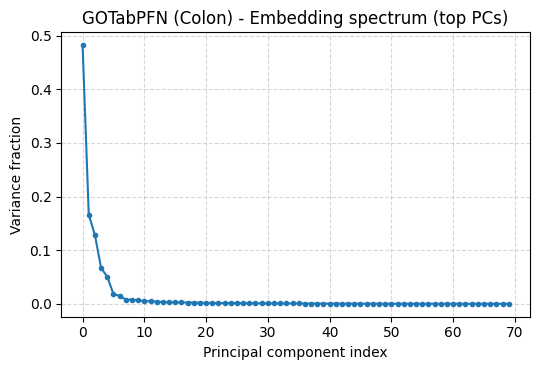

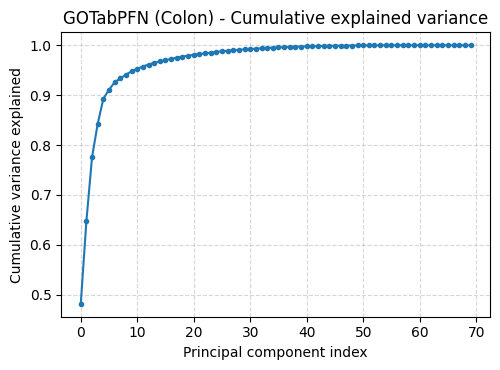


[Geom] Components needed for target variance:
   target_var  k_components
0        0.50             2
1        0.80             4
2        0.90             6
3        0.95            11
4        0.99            29

[kNN] Leave-one-out kNN accuracies in embedding space:
  k= 1:  74.19%
  k= 3:  75.81%
  k= 5:  82.26%
  k=10:  70.97%
  k=20:  69.35%


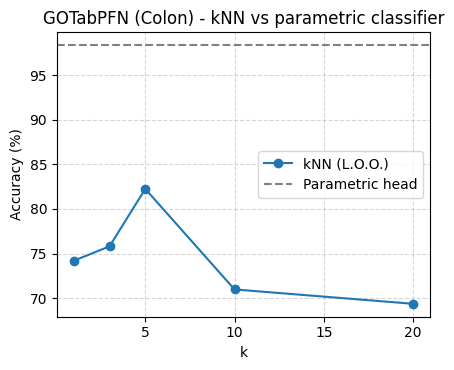


[Margin] Mean normalized margin (correct):  0.9707
[Margin] Mean normalized margin (incorrect): -0.0359


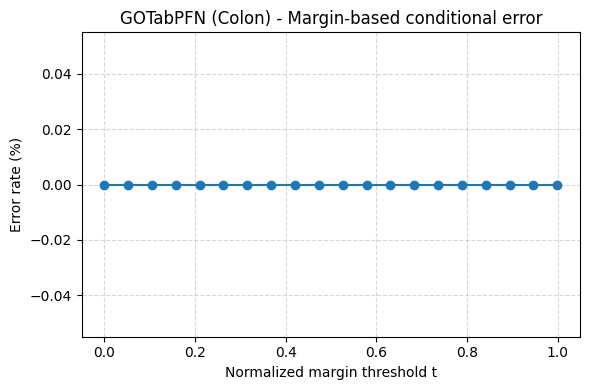

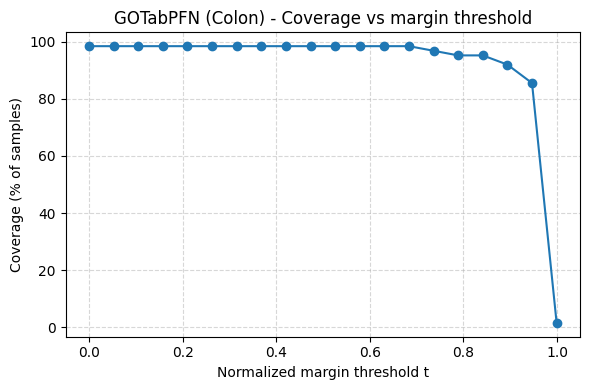


[Done] Theory-ish diagnostics (GOTabPFN, Colon) complete.
Saved figures:
  - gotabpfn_colon_embedding_spectrum.(png|pdf)
  - gotabpfn_colon_embedding_cumulative_variance.(png|pdf)
  - gotabpfn_colon_knn_vs_head.(png|pdf)
  - gotabpfn_colon_margin_conditional_error.(png|pdf)
  - gotabpfn_colon_margin_coverage.(png|pdf)


In [ ]:
# ============= Theory-ish diagnostics: geometry, kNN, margins (GOTabPFN, Colon) =============
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})

# -------------------------------------------------------------------
# 0. Sanity checks & base predictions
# -------------------------------------------------------------------
try:
    gotabpfn_predict_on_X
except NameError as e:
    raise RuntimeError(
        "gotabpfn_predict_on_X is not defined. "
        "Run the GOTabPFN cell where this helper is created."
    ) from e

try:
    X_all, y_all
except NameError as e:
    raise RuntimeError(
        "X_all / y_all not found. Make sure Colon data is loaded as X_all, y_all."
    ) from e

X_eval = np.asarray(X_all, dtype=np.float32)
y_eval = np.asarray(y_all, dtype=int)

print("[INFO] Theory-ish diagnostics for GOTabPFN on Colon")
print(f"[INFO] X_eval shape: {X_eval.shape}, y_eval shape: {y_eval.shape}")

# Run GOTabPFN once to get probs, preds, embeddings
probs, preds, Z_emb = gotabpfn_predict_on_X(X_eval)
y     = np.asarray(y_eval)
preds = np.asarray(preds)
embs  = np.asarray(Z_emb)

N, D = embs.shape
base_acc = accuracy_score(y, preds) * 100.0
print(f"[Info] N={N} samples, embedding dim={D}")
print(f"[Info] Base top-1 accuracy: {base_acc:.2f}%")

# -------------------------------------------------------------------
# 1. Representation spectrum & effective dimension
# -------------------------------------------------------------------
# Center embeddings
embs_c = embs - embs.mean(axis=0, keepdims=True)

# Covariance in embedding space (D x D)
# (rowvar=False => each column is a feature / dimension)
cov = np.cov(embs_c, rowvar=False)  # shape (D, D)

# Eigenvalues of covariance (variance along PCs)
evals, _ = np.linalg.eigh(cov)
evals = np.sort(np.maximum(evals, 0))[::-1]  # sort descending, clamp negatives

total_var = evals.sum() + 1e-12
explained = evals / total_var
cum_expl  = np.cumsum(explained)

# Effective dimension (participation ratio)
eff_dim = (total_var**2) / (np.sum(evals**2) + 1e-12)
print(f"\n[Geom] Effective dimension (participation ratio): {eff_dim:.1f}")

# Spectrum of top PCs
plt.figure(figsize=(5.5, 3.8))
plt.plot(explained[: min(100, D)], "-o", markersize=3)
plt.xlabel("Principal component index")
plt.ylabel("Variance fraction")
plt.title("GOTabPFN (Colon) - Embedding spectrum (top PCs)")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("gotabpfn_colon_embedding_spectrum.png", dpi=600, bbox_inches="tight")
plt.savefig("gotabpfn_colon_embedding_spectrum.pdf", dpi=600, bbox_inches="tight")
plt.show()

# Cumulative explained variance
plt.figure(figsize=(5.1, 3.8))
plt.plot(cum_expl[: min(100, D)], "-o", markersize=3)
plt.xlabel("Principal component index")
plt.ylabel("Cumulative variance explained")
plt.title("GOTabPFN (Colon) - Cumulative explained variance")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("gotabpfn_colon_embedding_cumulative_variance.png", dpi=600, bbox_inches="tight")
plt.savefig("gotabpfn_colon_embedding_cumulative_variance.pdf", dpi=600, bbox_inches="tight")
plt.show()

# Components needed for target variance levels
targets = [0.5, 0.8, 0.9, 0.95, 0.99]
rows = []
for t in targets:
    k = int(np.searchsorted(cum_expl, t) + 1)
    rows.append({"target_var": t, "k_components": k})
df_var = pd.DataFrame(rows)
print("\n[Geom] Components needed for target variance:")
print(df_var)

# -------------------------------------------------------------------
# 2. kNN classifier vs parametric head (in GOTabPFN embedding space)
# -------------------------------------------------------------------
ks = [1, 3, 5, 10, 20]
knn_accs = []

# We do leave-one-out style kNN by training on all embs,
# then ignoring the self-neighbor when computing predictions.
max_k = max(ks)
nbrs = KNeighborsClassifier(n_neighbors=max_k + 1, metric="euclidean")
nbrs.fit(embs, y)
dist, neigh_idx = nbrs.kneighbors(embs, return_distance=True)  # (N, max_k+1)

print("\n[kNN] Leave-one-out kNN accuracies in embedding space:")
for k in ks:
    # drop self (usually first neighbor)
    neigh_k = neigh_idx[:, 1 : k + 1]
    y_pred_knn = []
    for i in range(N):
        neigh_labels = y[neigh_k[i]]
        vals, counts = np.unique(neigh_labels, return_counts=True)
        y_pred_knn.append(vals[counts.argmax()])
    y_pred_knn = np.array(y_pred_knn)
    acc_k = accuracy_score(y, y_pred_knn) * 100.0
    knn_accs.append(acc_k)
    print(f"  k={k:2d}: {acc_k:6.2f}%")

plt.figure(figsize=(4.5, 3.8))
plt.plot(ks, knn_accs, "-o", label="kNN (L.O.O.)")
plt.axhline(base_acc, color="gray", linestyle="--", label="Parametric head")
plt.xlabel("k")
plt.ylabel("Accuracy (%)")
plt.title("GOTabPFN (Colon) - kNN vs parametric classifier")
plt.grid(True, ls="--", alpha=0.5)
plt.legend()
plt.tight_layout()
plt.savefig("gotabpfn_colon_knn_vs_head.png", dpi=600, bbox_inches="tight")
plt.savefig("gotabpfn_colon_knn_vs_head.pdf", dpi=600, bbox_inches="tight")
plt.show()

# -------------------------------------------------------------------
# 3. Margin-based view (probability margins)
#    margin = p_y(x) - max_{j≠y} p_j(x)
# -------------------------------------------------------------------
probs_np = np.asarray(probs)
true_probs = probs_np[np.arange(N), y]

tmp = probs_np.copy()
tmp[np.arange(N), y] = -1e9  # effectively remove true class
second_best = tmp.max(axis=1)
margins = true_probs - second_best  # in probability space

# Normalize by L2 norm of prob vector (optional)
prob_norm = np.linalg.norm(probs_np, axis=1) + 1e-12
norm_margins = margins / prob_norm

correct = (preds == y)
m_corr  = norm_margins[correct]
m_wrong = norm_margins[~correct]

print(f"\n[Margin] Mean normalized margin (correct):  {m_corr.mean():.4f}")
print(f"[Margin] Mean normalized margin (incorrect): {m_wrong.mean():.4f}")

# Margin-thresholded error rate & coverage
ths = np.linspace(0.0, np.percentile(norm_margins, 99), 20)
err_cond = []
cov_cond = []
for t in ths:
    idx = np.where(norm_margins >= t)[0]
    if len(idx) == 0:
        err_cond.append(np.nan)
        cov_cond.append(0.0)
    else:
        err_cond.append(1.0 - accuracy_score(y[idx], preds[idx]))
        cov_cond.append(len(idx) / N)

err_cond = np.array(err_cond) * 100.0  # %
cov_cond = np.array(cov_cond) * 100.0  # %

plt.figure(figsize=(6.0, 4.0))
plt.plot(ths, err_cond, "-o")
plt.xlabel("Normalized margin threshold t")
plt.ylabel("Error rate (%)")
plt.title("GOTabPFN (Colon) - Margin-based conditional error")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("gotabpfn_colon_margin_conditional_error.png", dpi=600, bbox_inches="tight")
plt.savefig("gotabpfn_colon_margin_conditional_error.pdf", dpi=600, bbox_inches="tight")
plt.show()

plt.figure(figsize=(6.0, 4.0))
plt.plot(ths, cov_cond, "-o")
plt.xlabel("Normalized margin threshold t")
plt.ylabel("Coverage (% of samples)")
plt.title("GOTabPFN (Colon) - Coverage vs margin threshold")
plt.grid(True, ls="--", alpha=0.5)
plt.tight_layout()
plt.savefig("gotabpfn_colon_margin_coverage.png", dpi=600, bbox_inches="tight")
plt.savefig("gotabpfn_colon_margin_coverage.pdf", dpi=600, bbox_inches="tight")
plt.show()

print("\n[Done] Theory-ish diagnostics (GOTabPFN, Colon) complete.")
print("Saved figures:")
print("  - gotabpfn_colon_embedding_spectrum.(png|pdf)")
print("  - gotabpfn_colon_embedding_cumulative_variance.(png|pdf)")
print("  - gotabpfn_colon_knn_vs_head.(png|pdf)")
print("  - gotabpfn_colon_margin_conditional_error.(png|pdf)")
print("  - gotabpfn_colon_margin_coverage.(png|pdf)")

# OOD and Local Sensitivity Diagnostics

[INFO] OOD + sensitivity diagnostics with GOTabPFN on Colon
[DATA] X_eval shape: (62, 2000), y_eval shape: (62,)
[ID] N=62, accuracy=98.39%
[ID] mean(max_conf)=0.967, mean(entropy)=0.106
[Noise] mean(max_conf)=0.810, mean(entropy)=0.424
[Perm ] mean(max_conf)=0.795,  mean(entropy)=0.446
[Const] mean(max_conf)=0.883, mean(entropy)=0.360


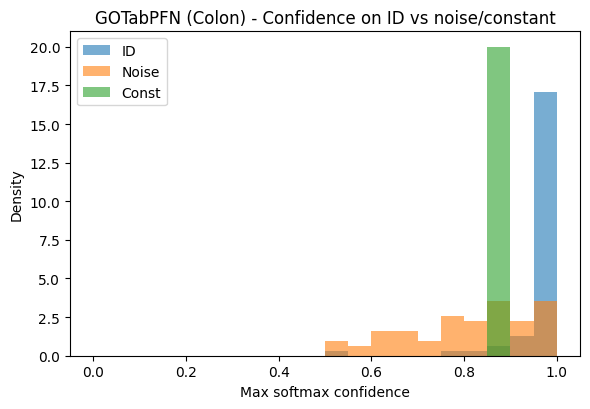

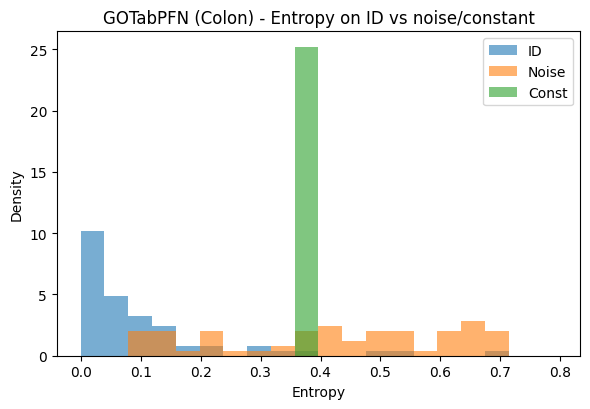


[Local sensitivity] eps=0.10, mean ratio=0.043, median=0.014


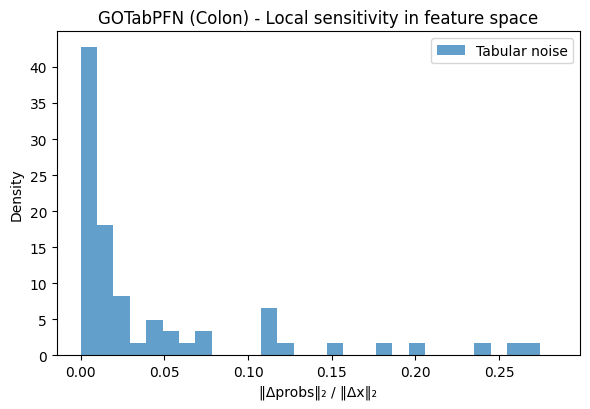


[Done] OOD + sensitivity diagnostics (GOTabPFN, Colon) complete.
Saved figures:
  - gotabpfn_colon_conf_id_vs_noise_const.(png|pdf)
  - gotabpfn_colon_entropy_id_vs_noise_const.(png|pdf)
  - gotabpfn_colon_local_sensitivity_tab.(png|pdf)


In [ ]:
# ===================== OOD + sensitivity diagnostics (GOTabPFN, Colon) =====================
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd
from sklearn.metrics import accuracy_score

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})

# ---- Sanity: helper + data ----
try:
    gotabpfn_predict_on_X
except NameError as e:
    raise RuntimeError(
        "gotabpfn_predict_on_X is not defined. "
        "Define it first (it should return probs, preds, Z_emb for X)."
    ) from e

try:
    X_all, y_all
except NameError as e:
    raise RuntimeError(
        "X_all / y_all not found. Make sure Colon data is loaded as X_all, y_all."
    ) from e

X_eval = np.asarray(X_all, dtype=np.float32)
y_eval = np.asarray(y_all, dtype=int)
N, M = X_eval.shape

print("[INFO] OOD + sensitivity diagnostics with GOTabPFN on Colon")
print(f"[DATA] X_eval shape: {X_eval.shape}, y_eval shape: {y_eval.shape}")

# ---------- 0. ID baseline stats ----------
probs_id, preds_id, Z_emb = gotabpfn_predict_on_X(X_eval)
probs_id = np.asarray(probs_id)
preds_id = np.asarray(preds_id)
y_id     = np.asarray(y_eval)

base_acc = accuracy_score(y_id, preds_id) * 100.0
maxconf_id = probs_id.max(axis=1)
entropy_id = -(probs_id * np.log(probs_id + 1e-12)).sum(axis=1)

print(f"[ID] N={len(y_id)}, accuracy={base_acc:.2f}%")
print(f"[ID] mean(max_conf)={maxconf_id.mean():.3f}, mean(entropy)={entropy_id.mean():.3f}")

# ---------- 1. Build OOD-ish tabular inputs ----------

np.random.seed(0)

# 1a) Gaussian noise features (same shape, ~N(0,1))
X_noise = np.random.normal(loc=0.0, scale=1.0, size=X_eval.shape).astype(np.float32)

# 1b) Column-shuffled features (break joint structure)
X_perm = X_eval.copy()
rng = np.random.default_rng(1)
for j in range(M):
    perm = rng.permutation(N)
    X_perm[:, j] = X_perm[perm, j]

# 1c) Constant "blank" features: dataset-wise mean per column
X_const = np.tile(X_eval.mean(axis=0, keepdims=True), (N, 1)).astype(np.float32)

# ---------- 1'. Run GOTabPFN on OOD sets ----------
def run_gotabpfn_on_array(X_arr):
    """
    X_arr: (N, M) float32
    Returns:
        probs, maxconf, entropy
    """
    probs, preds, _ = gotabpfn_predict_on_X(np.asarray(X_arr, dtype=np.float32))
    probs = np.asarray(probs)
    maxconf = probs.max(axis=1)
    entropy = -(probs * np.log(probs + 1e-12)).sum(axis=1)
    return probs, maxconf, entropy

_, maxconf_noise, entropy_noise = run_gotabpfn_on_array(X_noise)
_, maxconf_perm,  entropy_perm  = run_gotabpfn_on_array(X_perm)
_, maxconf_const, entropy_const = run_gotabpfn_on_array(X_const)

print(f"[Noise] mean(max_conf)={maxconf_noise.mean():.3f}, mean(entropy)={entropy_noise.mean():.3f}")
print(f"[Perm ] mean(max_conf)={maxconf_perm.mean():.3f},  mean(entropy)={entropy_perm.mean():.3f}")
print(f"[Const] mean(max_conf)={maxconf_const.mean():.3f}, mean(entropy)={entropy_const.mean():.3f}")

# ---------- 2. Confidence & entropy histograms ----------
bins_conf = np.linspace(0.0, 1.0, 21)

plt.figure(figsize=(6.0, 4.2))
plt.hist(maxconf_id,    bins=bins_conf, alpha=0.6, label="ID",    density=True)
plt.hist(maxconf_noise, bins=bins_conf, alpha=0.6, label="Noise", density=True)
plt.hist(maxconf_const, bins=bins_conf, alpha=0.6, label="Const", density=True)
plt.xlabel("Max softmax confidence")
plt.ylabel("Density")
plt.title("GOTabPFN (Colon) - Confidence on ID vs noise/constant")
plt.legend()
plt.tight_layout()
plt.savefig("gotabpfn_colon_conf_id_vs_noise_const.png", dpi=600, bbox_inches="tight")
plt.savefig("gotabpfn_colon_conf_id_vs_noise_const.pdf", dpi=600, bbox_inches="tight")
plt.show()

bins_ent = np.linspace(0.0, np.log(probs_id.shape[1]) + 0.1, 21)

plt.figure(figsize=(6.0, 4.2))
plt.hist(entropy_id,    bins=bins_ent, alpha=0.6, label="ID",    density=True)
plt.hist(entropy_noise, bins=bins_ent, alpha=0.6, label="Noise", density=True)
plt.hist(entropy_const, bins=bins_ent, alpha=0.6, label="Const", density=True)
plt.xlabel("Entropy")
plt.ylabel("Density")
plt.title("GOTabPFN (Colon) - Entropy on ID vs noise/constant")
plt.legend()
plt.tight_layout()
plt.savefig("gotabpfn_colon_entropy_id_vs_noise_const.png", dpi=600, bbox_inches="tight")
plt.savefig("gotabpfn_colon_entropy_id_vs_noise_const.pdf", dpi=600, bbox_inches="tight")
plt.show()

# ---------- 3. Local sensitivity (Lipschitz-ish in feature space) ----------
def local_sensitivity_gotabpfn(X_arr, eps=0.10, n_samples=200, batch_size=64):
    """
    Approximate local Lipschitz constant in probability-space:
        ratio = ||Δprobs||_2 / ||Δx||_2
    where Δx is small random L2-normalized noise in feature space.
    """
    X_arr = np.asarray(X_arr, dtype=np.float32)
    N_all, M_all = X_arr.shape
    n_use = min(n_samples, N_all)

    idx_all = np.random.choice(N_all, size=n_use, replace=False)
    ratios = []

    for start in range(0, n_use, batch_size):
        batch_idx = idx_all[start:start + batch_size]
        if len(batch_idx) == 0:
            break

        X0 = X_arr[batch_idx].astype(np.float32, copy=False)        # (B, M)
        B = X0.shape[0]

        # Random Gaussian noise, row-wise L2-normalized then scaled to eps
        noise = np.random.randn(*X0.shape).astype(np.float32)
        noise_flat = noise.reshape(B, -1)
        norm = np.linalg.norm(noise_flat, axis=1, keepdims=True) + 1e-12
        noise = noise / norm * eps
        noise_flat = noise.reshape(B, -1)
        inp_norm  = np.linalg.norm(noise_flat, axis=1)              # ~eps * sqrt(M)

        X1 = X0 + noise

        probs0, _, _ = gotabpfn_predict_on_X(X0)
        probs1, _, _ = gotabpfn_predict_on_X(X1)

        probs0 = np.asarray(probs0)
        probs1 = np.asarray(probs1)

        diff = probs1 - probs0
        diff_norm = np.linalg.norm(diff, axis=1)

        ratios.append(diff_norm / (inp_norm + 1e-12))

    return np.concatenate(ratios, axis=0)

sens_tab = local_sensitivity_gotabpfn(X_eval, eps=0.10, n_samples=200, batch_size=64)

print(f"\n[Local sensitivity] eps=0.10, mean ratio={sens_tab.mean():.3f}, median={np.median(sens_tab):.3f}")

plt.figure(figsize=(6.0, 4.2))
bins_s = np.linspace(0.0, sens_tab.max() * 1.05, 30)
plt.hist(sens_tab, bins=bins_s, alpha=0.7, label="Tabular noise", density=True)
plt.xlabel("‖Δprobs‖₂ / ‖Δx‖₂")
plt.ylabel("Density")
plt.title("GOTabPFN (Colon) - Local sensitivity in feature space")
plt.legend()
plt.tight_layout()
plt.savefig("gotabpfn_colon_local_sensitivity_tab.png", dpi=600, bbox_inches="tight")
plt.savefig("gotabpfn_colon_local_sensitivity_tab.pdf", dpi=600, bbox_inches="tight")
plt.show()

print("\n[Done] OOD + sensitivity diagnostics (GOTabPFN, Colon) complete.")
print("Saved figures:")
print("  - gotabpfn_colon_conf_id_vs_noise_const.(png|pdf)")
print("  - gotabpfn_colon_entropy_id_vs_noise_const.(png|pdf)")
print("  - gotabpfn_colon_local_sensitivity_tab.(png|pdf)")

# Deployment-Oriented Triage Diagnostics

[INFO] Deployment-style diagnostics with GOTabPFN on Colon
[DATA] X_eval shape: N=62, M=2000, y_eval shape=(62,)
[Info] N=62, num_classes=2
[Info] Base multiclass accuracy: 98.39%

[Triage] Using class 1 as positive vs others.
[Triage] Binary AUC (class 1 vs rest) = 1.000
[Triage] Chosen threshold th* = 0.7885 with sensitivity=1.000, specificity=1.000

[Triage] Confusion matrix at th* (rows=true, cols=pred):
          pred=0        pred=1
true=0         40           0
true=1          0          22

[Triage] Acc=100.00%, Prec=100.00%, Recall=100.00%


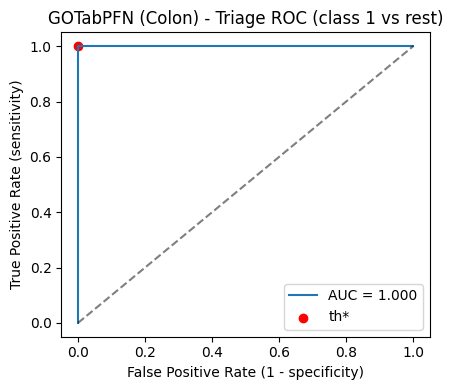


[Fairness] No `group_dict` found in globals; skipping fairness analysis.

[Reliability] Latency stats over 20 batches (GOTabPFN, Colon):
  mean = 639.07 ms/batch
  p50  = 638.30 ms/batch
  p90  = 644.48 ms/batch
  p99  = 648.91 ms/batch

[Done] Deployment-style diagnostics (triage + fairness + latency, GOTabPFN, Colon) complete.
If ROC ran, saved: gotabpfn_colon_triage_roc.(png|pdf)


In [ ]:
# ============== Deployment-style diagnostics: triage & fairness & latency (GOTabPFN, Colon) ==============
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time

from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
)

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})

# ----------------- 0) Hook GOTabPFN helper + Colon data -----------------
try:
    gotabpfn_predict_on_X
except NameError as e:
    raise RuntimeError(
        "gotabpfn_predict_on_X is not defined.\n"
        "You must have a helper like:\n"
        "    probs, preds, Z_emb = gotabpfn_predict_on_X(X_np)\n"
        "already defined from your GOTabPFN training/eval code."
    ) from e

try:
    X_all, y_all
except NameError as e:
    raise RuntimeError(
        "X_all / y_all not found. Make sure Colon data is loaded as X_all, y_all."
    ) from e

X_eval = np.asarray(X_all, dtype=np.float32)
y_eval = np.asarray(y_all, dtype=int)

N, M = X_eval.shape
print(f"[INFO] Deployment-style diagnostics with GOTabPFN on Colon")
print(f"[DATA] X_eval shape: N={N}, M={M}, y_eval shape={y_eval.shape}")

# ----------------- 1) Base predictions -----------------
probs, preds, Z_emb = gotabpfn_predict_on_X(X_eval)
probs = np.asarray(probs)
preds = np.asarray(preds)
y     = np.asarray(y_eval)

num_classes = probs.shape[1]
N = len(y)

base_acc = accuracy_score(y, preds) * 100.0
print(f"[Info] N={N}, num_classes={num_classes}")
print(f"[Info] Base multiclass accuracy: {base_acc:.2f}%")

# ----------------- 2) Triage-style binary task -----------------
# Choose which class index is considered "high-risk" positive.
# For Colon (binary), this can be 0 or 1 depending on your label encoding.
POSITIVE_CLASS_ID = 1   # <- change to 0 if needed

if POSITIVE_CLASS_ID < 0 or POSITIVE_CLASS_ID >= num_classes:
    raise ValueError(
        f"POSITIVE_CLASS_ID={POSITIVE_CLASS_ID} is out of range for {num_classes} classes."
    )

print(f"\n[Triage] Using class {POSITIVE_CLASS_ID} as positive vs others.")

# Binary labels: 1 if that class, else 0
y_bin = (y == POSITIVE_CLASS_ID).astype(int)

# Probability of positive class
pos_prob = probs[:, POSITIVE_CLASS_ID]

# Degenerate case: only one label in y_bin
if np.unique(y_bin).size < 2:
    print("\n[Triage] Warning: triage labels are degenerate "
          "(all positive or all negative). ROC/AUC undefined.")
else:
    fpr, tpr, ths = roc_curve(y_bin, pos_prob)
    roc_auc = auc(fpr, tpr)
    print(f"[Triage] Binary AUC (class {POSITIVE_CLASS_ID} vs rest) = {roc_auc:.3f}")

    # Target sensitivity (recall on positives)
    TARGET_SENS = 0.95
    sens = tpr
    spec = 1 - fpr

    valid_idx = np.where(sens >= TARGET_SENS)[0]
    if len(valid_idx) == 0:
        print(f"[Triage] No threshold achieves sensitivity ≥ {TARGET_SENS:.2f}; "
              f"taking max sensitivity point instead.")
        best_idx = np.argmax(sens)
    else:
        # Among thresholds with desired sensitivity, pick one with highest specificity
        best_idx = valid_idx[np.argmax(spec[valid_idx])]

    th_star   = ths[best_idx]
    sens_star = sens[best_idx]
    spec_star = spec[best_idx]
    print(f"[Triage] Chosen threshold th* = {th_star:.4f} "
          f"with sensitivity={sens_star:.3f}, specificity={spec_star:.3f}")

    # Confusion matrix at th*
    y_hat_bin = (pos_prob >= th_star).astype(int)
    cm = confusion_matrix(y_bin, y_hat_bin, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    print("\n[Triage] Confusion matrix at th* (rows=true, cols=pred):")
    print("          pred=0        pred=1")
    print(f"true=0     {tn:6d}      {fp:6d}")
    print(f"true=1     {fn:6d}      {tp:6d}")

    def bin_metrics(y_true, y_pred):
        acc  = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, zero_division=0)
        rec  = recall_score(y_true, y_pred, zero_division=0)
        return acc, prec, rec

    acc_star, prec_star, rec_star = bin_metrics(y_bin, y_hat_bin)
    print(f"\n[Triage] Acc={acc_star*100:.2f}%, "
          f"Prec={prec_star*100:.2f}%, Recall={rec_star*100:.2f}%")

    # ROC plot
    plt.figure(figsize=(4.5, 4.0))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0, 1], [0, 1], "k--", alpha=0.5)
    plt.scatter(fpr[best_idx], tpr[best_idx], c="red", label="th*")
    plt.xlabel("False Positive Rate (1 - specificity)")
    plt.ylabel("True Positive Rate (sensitivity)")
    plt.title(f"GOTabPFN (Colon) - Triage ROC (class {POSITIVE_CLASS_ID} vs rest)")
    plt.legend()
    plt.tight_layout()
    plt.savefig("gotabpfn_colon_triage_roc.png", dpi=600, bbox_inches="tight")
    plt.savefig("gotabpfn_colon_triage_roc.pdf", dpi=600, bbox_inches="tight")
    plt.show()

# ----------------- 3) Fairness-style slices (generic hook) -----------------
# To use this, define (aligned with X_all / y_all):
#   group_dict = {
#       "sex": np.array([...]),
#       "age_bucket": np.array([...]),
#       ...
#   }
# Each array must have length N.

if "group_dict" not in globals():
    print("\n[Fairness] No `group_dict` found in globals; skipping fairness analysis.")
else:
    group_dict_local = group_dict   # alias

    print("\n[Fairness] Running slices on triage task for groups in group_dict.")

    def show_slice_metrics(mask, name, y_bin_local, y_hat_local):
        if mask.sum() == 0:
            print(f"[Fairness] {name}: no samples.")
            return
        y_true_bin = y_bin_local[mask]
        y_pred_bin = y_hat_local[mask]

        cm = confusion_matrix(y_true_bin, y_pred_bin, labels=[0, 1])
        tn, fp, fn, tp = cm.ravel()
        sens = tp / (tp + fn + 1e-12)
        spec = tn / (tn + fp + 1e-12)
        acc  = accuracy_score(y_true_bin, y_pred_bin)
        print(f"[Fairness] {name}: n={mask.sum()}, "
              f"Acc={acc*100:.2f}%, Sens={sens*100:.2f}%, Spec={spec*100:.2f}%")

    if np.unique(y_bin).size < 2:
        print("[Fairness] Binary labels degenerate; fairness on triage not meaningful.")
    else:
        # If triage ROC ran, y_hat_bin is defined; otherwise default to 0.5
        if "y_hat_bin" not in globals():
            print("[Fairness] y_hat_bin not defined from triage ROC; using threshold 0.5.")
            y_hat_bin = (pos_prob >= 0.5).astype(int)

        for attr_name, g_arr in group_dict_local.items():
            g_arr = np.asarray(g_arr)
            if g_arr.shape[0] != N:
                print(f"[Fairness] Skipping {attr_name}: length {len(g_arr)} != N={N}")
                continue

            print(f"\n[Fairness] Attribute: {attr_name} (values={np.unique(g_arr)})")
            for v in np.unique(g_arr):
                mask = (g_arr == v)
                show_slice_metrics(mask, f"{attr_name}={v}", y_bin, y_hat_bin)

# ----------------- 4) Latency stats on this hardware -----------------
def measure_latency_gotabpfn(X, batch_size=64, num_batches=20):
    """
    Measure latency of GOTabPFN inference by repeatedly calling gotabpfn_predict_on_X
    on random mini-batches drawn from X.
    Returns an array of wall-clock times per batch (seconds).
    """
    X = np.asarray(X, dtype=np.float32)
    N_local = X.shape[0]
    times = []

    for b in range(num_batches):
        # sample a random batch (without worrying about overlap)
        if N_local <= batch_size:
            X_batch = X
        else:
            idx = np.random.choice(N_local, size=batch_size, replace=False)
            X_batch = X[idx]

        t0 = time.time()
        _probs, _preds, _Z = gotabpfn_predict_on_X(X_batch)
        t1 = time.time()
        times.append(t1 - t0)

    return np.array(times)

lat = measure_latency_gotabpfn(X_eval, batch_size=64, num_batches=20)
if len(lat) > 0:
    print("\n[Reliability] Latency stats over 20 batches (GOTabPFN, Colon):")
    print(f"  mean = {lat.mean()*1000:.2f} ms/batch")
    print(f"  p50  = {np.percentile(lat, 50)*1000:.2f} ms/batch")
    print(f"  p90  = {np.percentile(lat, 90)*1000:.2f} ms/batch")
    print(f"  p99  = {np.percentile(lat, 99)*1000:.2f} ms/batch")
else:
    print("\n[Reliability] Not enough batches for latency measurement.")

print("\n[Done] Deployment-style diagnostics (triage + fairness + latency, GOTabPFN, Colon) complete.")
print("If ROC ran, saved: gotabpfn_colon_triage_roc.(png|pdf)")

# Optuna Level Diagnostics: Global Search Behaviour

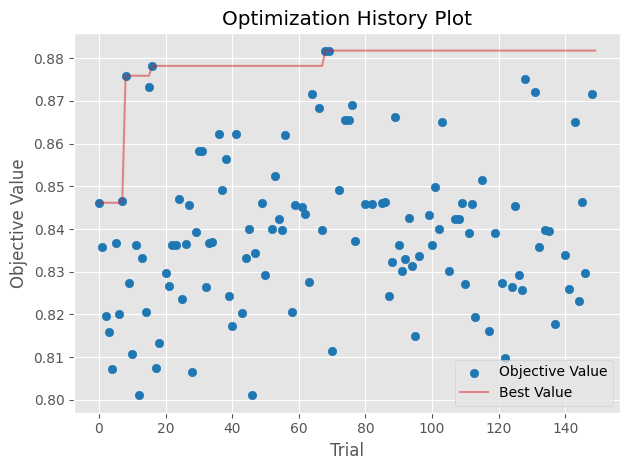

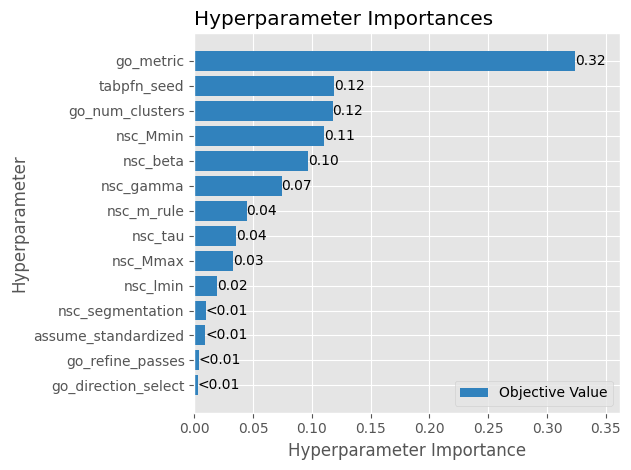

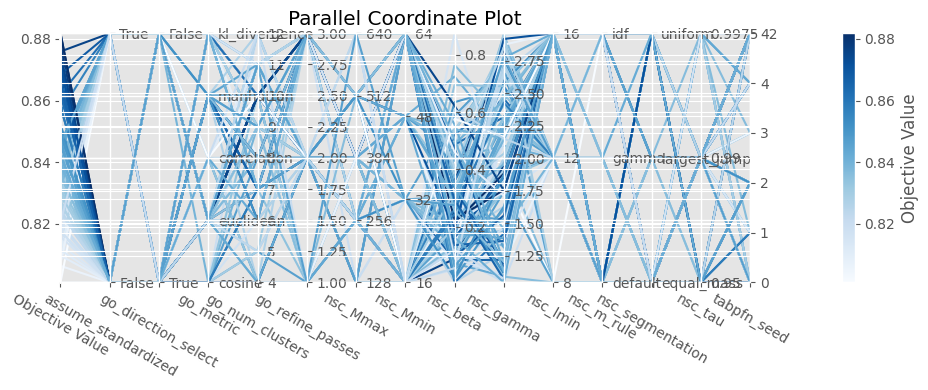

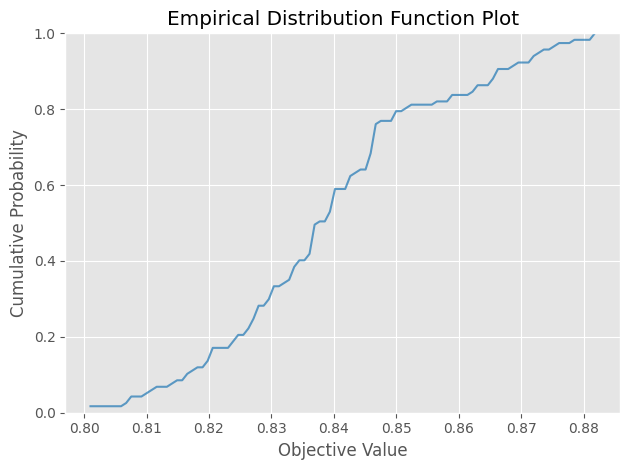

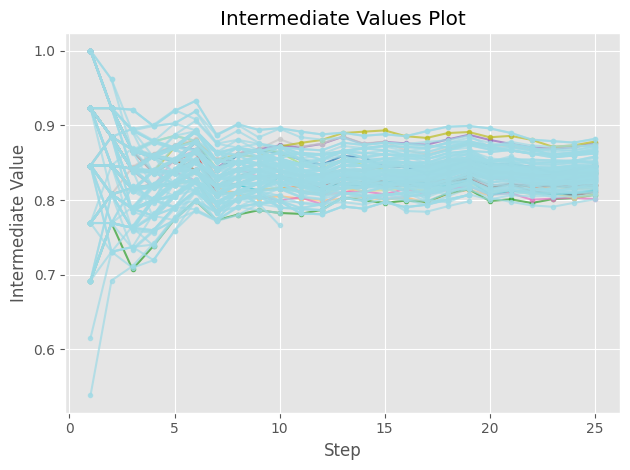


=== GOTabPFN (Colon) – Optuna trials (all states) summary ===
           number       value                 datetime_start  \
count  150.000000  150.000000                            150   
mean    74.500000    0.833953  2026-01-27 12:35:29.494516480   
min      0.000000    0.766026     2026-01-27 11:57:19.922151   
25%     37.250000    0.822621  2026-01-27 12:16:31.069439232   
50%     74.500000    0.835796  2026-01-27 12:35:01.203659520   
75%    111.750000    0.845833  2026-01-27 12:55:00.003152640   
max    149.000000    0.881795     2026-01-27 13:13:17.495338   
std     43.445368    0.020902                            NaN   

                   datetime_complete                   duration  \
count                            150                        150   
mean   2026-01-27 12:35:59.827955200  0 days 00:00:30.333438513   
min       2026-01-27 11:57:52.372484     0 days 00:00:14.694784   
25%    2026-01-27 12:17:02.085908224  0 days 00:00:28.421623500   
50%    2026-01-27 12:35:3

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import optuna

from optuna.visualization.matplotlib import (
    plot_optimization_history,
    plot_param_importances,
    plot_parallel_coordinate,
    plot_edf,
    plot_intermediate_values,
)

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})

# --------------------------------------------------
# Helper: auto-legend + show + save Axes/array-of-Axes
# --------------------------------------------------
def show_and_save(ax_like, fname, dpi=600, auto_legend=True):
    """
    ax_like can be:
      - a single Axes
      - an array/list of Axes
    For any Axes that already has a legend, move it to loc='best'
    iff auto_legend=True. Then save as PNG and display inline.
    """
    # Normalize to list of Axes
    if hasattr(ax_like, "figure"):
        axes = [ax_like]
        fig = ax_like.figure
    else:
        arr = np.array(ax_like).ravel()
        axes = [ax for ax in arr if hasattr(ax, "figure")]
        fig = axes[0].figure if axes else plt.gcf()

    # Move legends to best location if requested
    if auto_legend and axes:
        for ax in axes:
            leg = ax.get_legend()
            if leg is not None:
                ax.legend(loc="best")

    fig.tight_layout()
    fig.savefig(fname, dpi=dpi, bbox_inches="tight")
    plt.show()
    plt.close(fig)


# ==================================================
# 1) Optimization history
# ==================================================
ax_hist = plot_optimization_history(study)
show_and_save(ax_hist, "gotabpfn_colon_opt_history.png", auto_legend=True)

# ==================================================
# 2) Hyperparameter importance
# ==================================================
ax_imp = plot_param_importances(study)
show_and_save(ax_imp, "gotabpfn_colon_hyp_importance.png", auto_legend=True)

# ==================================================
# 3) Parallel coordinate plot (stretch x-axis)
# ==================================================
ax_pc = plot_parallel_coordinate(study)

# Make it wider horizontally so the parameters are less compressed
fig_pc = ax_pc.figure
fig_pc.set_size_inches(10.0, 4.0)  # wider than default
show_and_save(ax_pc, "gotabpfn_colon_parallel.png", auto_legend=True)

# ==================================================
# 4) Empirical distribution function (EDF)
# ==================================================
ax_edf = plot_edf(study)
show_and_save(ax_edf, "gotabpfn_colon_edf.png", auto_legend=True)

# ==================================================
# 5) Intermediate values plot (NO legend)
# ==================================================
ax_inter = plot_intermediate_values(study)

# Explicitly remove any legend if Optuna adds one
leg_inter = ax_inter.get_legend()
if leg_inter is not None:
    leg_inter.remove()

show_and_save(ax_inter, "gotabpfn_colon_intermediate_values.png", auto_legend=False)

# ==================================================
# 6) Trials DataFrame + correlations (same as before)
# ==================================================
df_trials = study.trials_dataframe()

print("\n=== GOTabPFN (Colon) – Optuna trials (all states) summary ===")
print(df_trials.describe())

# Only COMPLETE trials for correlation analysis
df_complete = df_trials[df_trials["state"] == "COMPLETE"].copy()
print(f"\n# COMPLETE trials: {len(df_complete)} / {len(df_trials)}")

param_cols = [c for c in df_complete.columns if c.startswith("params_")]
num_cols = df_complete[param_cols + ["value"]].select_dtypes(include=[np.number]).columns

corr_to_value = df_complete[num_cols].corr()["value"].sort_values(ascending=False)

print("\n=== Correlation of numeric hyperparameters with objective value ===")
print(corr_to_value)

print("\n=== Top-10 trials by value (descending) ===")
print(
    df_complete.sort_values("value", ascending=False)[
        ["number", "value"] + param_cols
    ].head(10)
)

# GOTabPFN Ablation Studies

In [ ]:
# ============================================================
# GOTabPFN Ablation Studies (Colon, 5x5 CV)
# ============================================================
import os, numpy as np, pandas as pd, torch
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RepeatedStratifiedKFold
from tqdm import tqdm

# ---------- Ensure key globals exist ----------

# 1) best_params (from study or from your pasted values)
try:
    best_params  # noqa
except NameError:
    try:
        best_params = study.best_trial.params
        print("[INFO] best_params loaded from study.best_trial.params")
    except NameError:
        print("[WARN] study not found; using hard-coded best_params from your log.")
        best_params = {
            "go_metric": "euclidean",
            "go_num_clusters": 10,
            "go_refine_passes": 3,
            "go_direction_select": True,
            "nsc_segmentation": "equal_mass",
            "nsc_m_rule": "idf",
            "nsc_tau": 0.99,
            "nsc_gamma": 1.7570143129240916,
            "nsc_beta": 0.2244046472232107,
            "nsc_Mmin": 64,
            "nsc_Mmax": 384,
            "nsc_lmin": 16,
            "assume_standardized": False,
            "tabpfn_seed": 42,
        }

# 2) NUM_CLASSES
try:
    NUM_CLASSES  # noqa
except NameError:
    NUM_CLASSES = len(np.unique(y_all))
    print(f"[INFO] NUM_CLASSES set from y_all: {NUM_CLASSES}")

# 3) PIDFSegPCA alias
try:
    PIDFSegPCA  # noqa
except NameError:
    PIDFSegPCA = pidf_segpca
    print("[INFO] PIDFSegPCA alias -> pidf_segpca")

# 4) CV splitter
try:
    rkf  # noqa
except NameError:
    print("[WARN] rkf not found; creating new 5x5 RepeatedStratifiedKFold with SEED=42.")
    SEED = 42
    rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=SEED)
else:
    SEED = 42  # keep consistent

# 5) Devices
try:
    NSC_DEVICE  # noqa
    TABPFN_DEVICE  # noqa
except NameError:
    NSC_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    TABPFN_DEVICE = NSC_DEVICE
    print(f"[INFO] NSC_DEVICE={NSC_DEVICE}, TABPFN_DEVICE={TABPFN_DEVICE}")

TASK_TYPE = "binary" if NUM_CLASSES == 2 else "multiclass"

# ---------- Utils ----------
def seed_everything(seed: int = 42):
    import random
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def cleanup_cuda():
    import gc
    gc.collect()
    if torch.cuda.is_available():
        try:
            torch.cuda.synchronize()
        except Exception:
            pass
        torch.cuda.empty_cache()

# ---------- GO-LR helper ----------
def get_pi_star(ordering_mode: str,
                X_all: np.ndarray,
                go_params: dict,
                seed: int = 42):
    """
    ordering_mode ∈ {"go", "identity", "random"}.
    Returns:
        Pi_star (list[int]) or None (if no ordering used).
    """
    m = X_all.shape[1]
    ordering_mode = ordering_mode.lower()

    if ordering_mode == "identity":
        return list(range(m))

    if ordering_mode == "random":
        rng = np.random.RandomState(seed)
        return rng.permutation(m).tolist()

    if ordering_mode == "go":
        go = GraphFeatureOrdering(
            num_clusters=int(go_params.get("go_num_clusters", 7)),
            metric=go_params.get("go_metric", "correlation"),
            refine=True,
            direction_select=bool(go_params.get("go_direction_select", True)),
            refine_passes=int(go_params.get("go_refine_passes", 1)),
        )
        try:
            Pi_star, _, _, _ = go.fit(
                X_all,
                seed=seed,
                deterministic=True,
                use_cpu_kmeans=False
            )
        except RuntimeError:
            cleanup_cuda()
            Pi_star, _, _, _ = go.fit(
                X_all,
                seed=seed,
                deterministic=True,
                use_cpu_kmeans=True
            )
        return Pi_star

    raise ValueError(f"Unknown ordering_mode: {ordering_mode}")

# ---------- NSC helper ----------
def build_nsc_and_compress(
    X_tr: np.ndarray,
    X_va: np.ndarray,
    Pi_star: list[int],
    nsc_params: dict,
    compress_mode: str = "flatten",
    seg_override: str | None = None,
    m_rule_override: str | None = None,
    use_transition_aware: bool = True,
):
    """
    Build PIDFSegPCA, configure, and compress train/val.
    Returns:
        Z_tr (np.ndarray), Z_va (np.ndarray)
    """
    compress_mode = compress_mode.lower()

    seg = seg_override if seg_override is not None else nsc_params.get("nsc_segmentation", "uniform")
    m_rule = m_rule_override if m_rule_override is not None else nsc_params.get("nsc_m_rule", "default")

    nsc = PIDFSegPCA(
        segmentation=seg,
        l_min=int(nsc_params.get("nsc_lmin", 8)),
        m_rule=m_rule,
        gamma=float(nsc_params.get("nsc_gamma", 2.0)),
        beta=float(nsc_params.get("nsc_beta", 0.5)),
        tau=float(nsc_params.get("nsc_tau", 0.99)),
        M_min=int(nsc_params.get("nsc_Mmin", 32)),
        M_max=int(nsc_params.get("nsc_Mmax", 512)),
        assume_standardized=bool(nsc_params.get("assume_standardized", True)),
        device=NSC_DEVICE,
    )

    deltas = None
    if seg != "uniform" and use_transition_aware:
        deltas = compute_deltas_adjacent_corr(X_tr, Pi_star)
    if seg != "uniform" and not use_transition_aware:
        seg = "uniform"
        nsc.segmentation = "uniform"
        deltas = None

    X_tr_t = torch.from_numpy(X_tr)
    nsc.configure(Pi_star=Pi_star, X_train=X_tr_t, tau=float(nsc_params.get("nsc_tau", 0.99)), deltas=deltas)

    Z_tr = nsc.compress(X_tr_t, mode=compress_mode).cpu().numpy()
    Z_va = nsc.compress(torch.from_numpy(X_va), mode=compress_mode).cpu().numpy()
    return Z_tr, Z_va

# ---------- Classifier helpers ----------
def fit_tabpfn_head(Z_tr, y_tr, random_state: int = 42):
    cfg = TabPFN25Config(
        task_type=TASK_TYPE,
        num_classes=int(NUM_CLASSES),
        device=TABPFN_DEVICE,
        random_state=int(random_state),
    )
    head = TabPFN25Head(cfg)
    head.fit(Z_tr, y_tr)
    return head

def fit_logreg_head(Z_tr, y_tr):
    clf = LogisticRegression(
        penalty="l2",
        C=1.0,
        solver="lbfgs",
        max_iter=2000,
        n_jobs=-1,
    )
    clf.fit(Z_tr, y_tr)
    return clf

# ---------- Core 5x5 CV evaluator ----------
def evaluate_ablation(
    name: str,
    X_all: np.ndarray,
    y_all: np.ndarray,
    ordering_mode: str = "go",    # "go" | "identity" | "random" | "none"
    use_nsc: bool = True,
    compress_mode: str = "flatten",  # "flatten" | "mean"
    seg_override: str | None = None,
    m_rule_override: str | None = None,
    use_transition_aware: bool = True,
    classifier_type: str = "tabpfn",  # "tabpfn" | "logreg"
    tabpfn_seed: int = 42,
    verbose: bool = True,
):
    seed_everything(SEED)

    Pi_star_global = None
    if use_nsc and ordering_mode != "none":
        Pi_star_global = get_pi_star(ordering_mode, X_all, best_params, seed=SEED)

    accs = []

    if verbose:
        print(f"\n===== Ablation: {name} =====")
        print(f"  ordering_mode={ordering_mode}, use_nsc={use_nsc}, "
              f"compress_mode={compress_mode}, classifier={classifier_type}")

    for fold_id, (tr_idx, va_idx) in enumerate(rkf.split(X_all, y_all), start=1):
        X_tr = X_all[tr_idx]
        y_tr = y_all[tr_idx]
        X_va = X_all[va_idx]
        y_va = y_all[va_idx]

        if use_nsc:
            Pi_star = Pi_star_global
            Z_tr, Z_va = build_nsc_and_compress(
                X_tr,
                X_va,
                Pi_star=Pi_star,
                nsc_params=best_params,
                compress_mode=compress_mode,
                seg_override=seg_override,
                m_rule_override=m_rule_override,
                use_transition_aware=use_transition_aware,
            )
        else:
            Z_tr, Z_va = X_tr, X_va

        if classifier_type == "tabpfn":
            head = fit_tabpfn_head(Z_tr, y_tr, random_state=tabpfn_seed)
            P = head.predict_proba(Z_va)
            pred = np.argmax(P, axis=1)
        elif classifier_type == "logreg":
            clf = fit_logreg_head(Z_tr, y_tr)
            pred = clf.predict(Z_va)
        else:
            raise ValueError(f"Unknown classifier_type: {classifier_type}")

        acc = float(accuracy_score(y_va, pred))
        accs.append(acc)
        cleanup_cuda()

    mean_acc = float(np.mean(accs))
    std_acc = float(np.std(accs, ddof=1))
    if verbose:
        print(f"[{name}] mean_acc = {mean_acc*100:.2f}% ± {std_acc*100:.2f}%")

    return {
        "name": name,
        "ordering_mode": ordering_mode,
        "use_nsc": use_nsc,
        "compress_mode": compress_mode,
        "seg_override": seg_override if seg_override is not None else best_params.get("nsc_segmentation", "uniform"),
        "m_rule_override": m_rule_override if m_rule_override is not None else best_params.get("nsc_m_rule", "default"),
        "use_transition_aware": use_transition_aware,
        "classifier_type": classifier_type,
        "mean_acc": mean_acc,
        "std_acc": std_acc,
    }

# ---------- Define ablation suite ----------
ablations = [
    # 0) Baseline: GO-LR + NSC (PCA tokens) + TabPFN
    dict(
        name="baseline_go_nsc_tabpfn",
        ordering_mode="go",
        use_nsc=True,
        compress_mode="flatten",
        seg_override=None,
        m_rule_override=None,
        use_transition_aware=True,
        classifier_type="tabpfn",
    ),

    # 1) No ordering: identity Pi*
    dict(
        name="identity_order_nsc_tabpfn",
        ordering_mode="identity",
        use_nsc=True,
        compress_mode="flatten",
        seg_override=None,
        m_rule_override=None,
        use_transition_aware=True,
        classifier_type="tabpfn",
    ),

    # 2) Random ordering
    dict(
        name="random_order_nsc_tabpfn",
        ordering_mode="random",
        use_nsc=True,
        compress_mode="flatten",
        seg_override=None,
        m_rule_override=None,
        use_transition_aware=True,
        classifier_type="tabpfn",
    ),

    # 3) No NSC: raw TabPFN on X
    dict(
        name="no_nsc_raw_tabpfn",
        ordering_mode="none",
        use_nsc=False,
        compress_mode="flatten",
        seg_override=None,
        m_rule_override=None,
        use_transition_aware=False,
        classifier_type="tabpfn",
    ),

    # 4) NSC uniform vs transition-aware
    dict(
        name="uniform_seg_nsc_tabpfn",
        ordering_mode="go",
        use_nsc=True,
        compress_mode="flatten",
        seg_override="uniform",
        m_rule_override=None,
        use_transition_aware=False,
        classifier_type="tabpfn",
    ),
    dict(
        name="transition_seg_nsc_tabpfn",
        ordering_mode="go",
        use_nsc=True,
        compress_mode="flatten",
        seg_override="equal_mass",  # or "largest_jump"
        m_rule_override=None,
        use_transition_aware=True,
        classifier_type="tabpfn",
    ),

    # 5) PCA tokens vs mean pooling
    dict(
        name="nsc_pca_tokens_tabpfn",
        ordering_mode="go",
        use_nsc=True,
        compress_mode="flatten",
        seg_override=None,
        m_rule_override=None,
        use_transition_aware=True,
        classifier_type="tabpfn",
    ),
    dict(
        name="nsc_mean_tokens_tabpfn",
        ordering_mode="go",
        use_nsc=True,
        compress_mode="mean",
        seg_override=None,
        m_rule_override=None,
        use_transition_aware=True,
        classifier_type="tabpfn",
    ),

    # 6) NSC + identity ordering (interaction)
    dict(
        name="identity_order_nsc_pca_tabpfn",
        ordering_mode="identity",
        use_nsc=True,
        compress_mode="flatten",
        seg_override=None,
        m_rule_override=None,
        use_transition_aware=True,
        classifier_type="tabpfn",
    ),

    # 7) Alt head: GO-LR + NSC + Logistic Regression
    dict(
        name="go_nsc_logreg",
        ordering_mode="go",
        use_nsc=True,
        compress_mode="flatten",
        seg_override=None,
        m_rule_override=None,
        use_transition_aware=True,
        classifier_type="logreg",
    ),
]

# ---------- Run ablations ----------
results = []
for cfg in tqdm(ablations):
    res = evaluate_ablation(
        name=cfg["name"],
        X_all=X_all,
        y_all=y_all,
        ordering_mode=cfg["ordering_mode"],
        use_nsc=cfg["use_nsc"],
        compress_mode=cfg["compress_mode"],
        seg_override=cfg["seg_override"],
        m_rule_override=cfg["m_rule_override"],
        use_transition_aware=cfg["use_transition_aware"],
        classifier_type=cfg["classifier_type"],
        tabpfn_seed=int(best_params.get("tabpfn_seed", 42)),
        verbose=True,
    )
    results.append(res)

df_ablate = pd.DataFrame(results)
print("\n================ Ablation Summary (GOTabPFN, Colon, 5x5 CV) ================")
print(df_ablate[[
    "name",
    "mean_acc",
    "std_acc",
    "ordering_mode",
    "use_nsc",
    "compress_mode",
    "seg_override",
    "classifier_type",
]].sort_values("mean_acc", ascending=False))

# Optionally save:
df_ablate.to_csv("gotabpfn_colon_ablation_summary.csv", index=False)

[INFO] best_params loaded from study.best_trial.params


  0%|                                                    | 0/10 [00:00<?, ?it/s]


===== Ablation: baseline_go_nsc_tabpfn =====
  ordering_mode=go, use_nsc=True, compress_mode=flatten, classifier=tabpfn


 10%|████▍                                       | 1/10 [00:42<06:26, 42.97s/it]

[baseline_go_nsc_tabpfn] mean_acc = 88.18% ± 10.05%

===== Ablation: identity_order_nsc_tabpfn =====
  ordering_mode=identity, use_nsc=True, compress_mode=flatten, classifier=tabpfn


...

 90%|███████████████████████████████████████▌    | 9/10 [05:40<00:36, 36.17s/it]

[identity_order_nsc_pca_tabpfn] mean_acc = 81.67% ± 11.91%

===== Ablation: go_nsc_logreg =====
  ordering_mode=go, use_nsc=True, compress_mode=flatten, classifier=logreg


100%|███████████████████████████████████████████| 10/10 [07:10<00:00, 43.09s/it]

[go_nsc_logreg] mean_acc = 82.67% ± 11.05%

================ Ablation Summary (GOTabPFN, Colon, 5x5 CV) ================
                            name  mean_acc   std_acc ordering_mode  use_nsc  \
0         baseline_go_nsc_tabpfn  0.881795  0.100542            go     True   
5      transition_seg_nsc_tabpfn  0.881795  0.100542            go     True   
6          nsc_pca_tokens_tabpfn  0.881795  0.100542            go     True   
3              no_nsc_raw_tabpfn  0.868462  0.091634          none    False   
2        random_order_nsc_tabpfn  0.842051  0.103443        random     True   
9                  go_nsc_logreg  0.826667  0.110542            go     True   
1      identity_order_nsc_tabpfn  0.816667  0.119051      identity     True   
8  identity_order_nsc_pca_tabpfn  0.816667  0.119051      identity     True   
4         uniform_seg_nsc_tabpfn  0.800000  0.113046            go     True   
7         nsc_mean_tokens_tabpfn  0.645897  0.036697            go     True   

  compres


[W127 20:54:53.559429982 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())
[W127 20:54:57.741515954 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())
[W127 20:55:00.889103782 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())
[W127 20:55:03.211274412 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())
[W127 20:55:06.394904719 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())
[W127 20:55:09.577903885 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, use PYTORCH_ALLOC_CONF instead (function operator())
[W127 20:55:13.761172766 AllocatorConfig.cpp:28] Warning: PYTORCH_CUDA_ALLOC_CONF is deprecated, us

# GPU/CPU memory usage

In [ ]:
# ============================================================
# GOTabPFN 5x5 CV run with timing + GPU/CPU memory metrics
# ============================================================
import os, time, psutil, random
import numpy as np
import torch
from sklearn.metrics import accuracy_score

# ---------------- Helpers: seeding, CUDA cleanup ----------------
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)

def cleanup_cuda():
    if torch.cuda.is_available():
        try:
            torch.cuda.synchronize()
        except Exception:
            pass
        torch.cuda.empty_cache()

# ---------------- Helpers: timing + memory ----------------
def run_and_measure_gpu(train_fn, *args, **kwargs):
    """
    Wrap a training/eval function:
      - clears CUDA cache
      - resets peak memory
      - times wall clock
      - returns result + time + peak GPU MB
    """
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    t0 = time.time()
    result = train_fn(*args, **kwargs)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t1 = time.time()

    peak_mem_mb = None
    if torch.cuda.is_available():
        peak_bytes = torch.cuda.max_memory_allocated()
        peak_mem_mb = peak_bytes / 1024**2

    return {
        "result": result,
        "time_sec": t1 - t0,
        "gpu_peak_mb": peak_mem_mb,
    }

def get_cpu_mem_mb():
    proc = psutil.Process(os.getpid())
    return proc.memory_info().rss / 1024**2

# ---------------- Best hyperparameters (from Optuna) ----------------
best_params = {
    "go_metric": "euclidean",
    "go_num_clusters": 10,
    "go_refine_passes": 3,
    "go_direction_select": True,
    "nsc_segmentation": "equal_mass",
    "nsc_m_rule": "idf",
    "nsc_tau": 0.99,
    "nsc_gamma": 1.7570143129240916,
    "nsc_beta": 0.2244046472232107,
    "nsc_Mmin": 64,
    "nsc_Mmax": 384,
    "nsc_lmin": 16,
    "assume_standardized": False,
    "tabpfn_seed": 42,
}

# Sanity checks for globals from your main GOTabPFN cell
assert "X_all" in globals() and "y_all" in globals(), "X_all / y_all not found."
assert "NUM_CLASSES" in globals(), "NUM_CLASSES not found."
assert "rkf" in globals(), "rkf (RepeatedStratifiedKFold) not found."
assert "NSC_DEVICE" in globals(), "NSC_DEVICE not defined."
assert "TABPFN_DEVICE" in globals(), "TABPFN_DEVICE not defined."
assert "GraphFeatureOrdering" in globals(), "GraphFeatureOrdering not defined."
assert "PIDFSegPCA" in globals(), "PIDFSegPCA not defined."
assert "TabPFN25Head" in globals(), "TabPFN25Head not defined."
assert "TabPFN25Config" in globals(), "TabPFN25Config not defined."
assert "compute_deltas_adjacent_corr" in globals(), "compute_deltas_adjacent_corr not defined."

SEED = 42
TASK_TYPE = "binary" if NUM_CLASSES == 2 else "multiclass"

# ---------------- Core: one full 5x5 CV run with fixed params ----------------
def run_gotabpfn_5x5cv_with_params(params: dict):
    """
    One GOTabPFN + NSC + TabPFN25 5x5 CV run on (X_all, y_all)
    using a fixed hyperparameter dictionary.

    Returns:
        {
          "mean_acc": float,
          "std_acc": float,
          "fold_accs": list[float],
        }
    """
    seed_everything(SEED)

    # --- Unpack params ---
    go_metric          = params["go_metric"]
    go_k               = int(params["go_num_clusters"])
    go_refine_passes   = int(params["go_refine_passes"])
    go_direction       = bool(params["go_direction_select"])

    nsc_seg            = params["nsc_segmentation"]
    nsc_m_rule         = params["nsc_m_rule"]
    nsc_tau            = float(params["nsc_tau"])
    nsc_gamma          = float(params["nsc_gamma"])
    nsc_beta           = float(params["nsc_beta"])
    nsc_Mmin           = int(params["nsc_Mmin"])
    nsc_Mmax           = int(params["nsc_Mmax"])
    nsc_lmin           = int(params["nsc_lmin"])
    assume_standardized = bool(params["assume_standardized"])

    tabpfn_seed        = int(params["tabpfn_seed"])

    # --- GO-LR once on full data ---
    print(f"[GO-LR] metric={go_metric}, k={go_k}, refine_passes={go_refine_passes}, "
          f"direction_select={go_direction}")
    go = GraphFeatureOrdering(
        num_clusters=go_k,
        metric=go_metric,
        refine=True,
        direction_select=go_direction,
        refine_passes=go_refine_passes,
    )

    try:
        # prefer GPU k-means if available
        Pi_star, _, _, _ = go.fit(X_all, seed=SEED, deterministic=True, use_cpu_kmeans=False)
    except RuntimeError:
        print("[GO-LR] GPU k-means failed; falling back to CPU k-means.")
        cleanup_cuda()
        Pi_star, _, _, _ = go.fit(X_all, seed=SEED, deterministic=True, use_cpu_kmeans=True)

    print(f"[GO-LR] Got global ordering of length {len(Pi_star)}.")

    # --- TabPFN config ---
    head_cfg = TabPFN25Config(
        task_type=TASK_TYPE,
        num_classes=int(NUM_CLASSES),
        device=TABPFN_DEVICE,
        random_state=tabpfn_seed,
    )

    # --- 5x5 CV ---
    accs = []
    for fold_id, (tr_idx, va_idx) in enumerate(rkf.split(X_all, y_all), start=1):
        X_tr = X_all[tr_idx]
        y_tr = y_all[tr_idx]
        X_va = X_all[va_idx]
        y_va = y_all[va_idx]

        # NSC instance per fold
        nsc = PIDFSegPCA(
            segmentation=nsc_seg,
            l_min=nsc_lmin,
            m_rule=nsc_m_rule,
            gamma=nsc_gamma,
            beta=nsc_beta,
            tau=nsc_tau,
            M_min=nsc_Mmin,
            M_max=nsc_Mmax,
            assume_standardized=assume_standardized,
            device=NSC_DEVICE,
        )

        deltas = None if nsc_seg == "uniform" else compute_deltas_adjacent_corr(X_tr, Pi_star)

        X_tr_t = torch.from_numpy(X_tr)
        nsc.configure(Pi_star=Pi_star, X_train=X_tr_t, tau=nsc_tau, deltas=deltas)

        Z_tr = nsc.compress(X_tr_t, mode="flatten").cpu().numpy()
        Z_va = nsc.compress(torch.from_numpy(X_va), mode="flatten").cpu().numpy()

        # TabPFN head per fold
        head = TabPFN25Head(head_cfg)
        head.fit(Z_tr, y_tr)

        P = head.predict_proba(Z_va)
        pred = np.argmax(P, axis=1)
        acc = float(accuracy_score(y_va, pred))
        accs.append(acc)

        print(f"[Fold {fold_id:2d}/25] acc = {acc*100:.2f}%")

        cleanup_cuda()

    mean_acc = float(np.mean(accs))
    std_acc  = float(np.std(accs, ddof=1)) if len(accs) > 1 else 0.0

    print("\n[RESULT] GOTabPFN 5x5 CV summary:")
    print(f"  mean_acc = {mean_acc*100:.2f}%")
    print(f"  std_acc  = {std_acc*100:.2f}%")
    return {
        "mean_acc": mean_acc,
        "std_acc": std_acc,
        "fold_accs": accs,
    }

# ---------------- Wrapper: single run for measurement ----------------
def train_gotabpfn_colon_once():
    """
    Wrapper used by run_and_measure_gpu; returns the CV summary dict.
    """
    return run_gotabpfn_5x5cv_with_params(best_params)

# ---------------- Actually run + print metrics ----------------
stats = run_and_measure_gpu(train_gotabpfn_colon_once)
res = stats["result"]

print("\n================ Performance & Resource Usage ================")
print(f"Mean CV accuracy : {res['mean_acc']*100:.2f}%")
print(f"Std CV accuracy  : {res['std_acc']*100:.2f}%")
print(f"Num folds        : {len(res['fold_accs'])}")

print(f"\nWall-clock time  : {stats['time_sec']:.2f} seconds")
if stats["gpu_peak_mb"] is not None:
    print(f"Peak GPU memory  : {stats['gpu_peak_mb']:.1f} MB")
else:
    print("Peak GPU memory  : (no CUDA available)")

print(f"Current CPU RSS  : {get_cpu_mem_mb():.1f} MB")
print("==============================================================")

[GO-LR] metric=euclidean, k=10, refine_passes=3, direction_select=True
[GO-LR] Got global ordering of length 2000.
[Fold  1/25] acc = 100.00%
[Fold  2/25] acc = 84.62%
[Fold  3/25] acc = 91.67%
[Fold  4/25] acc = 83.33%
[Fold  5/25] acc = 100.00%
[Fold  6/25] acc = 100.00%
[Fold  7/25] acc = 61.54%
[Fold  8/25] acc = 100.00%
[Fold  9/25] acc = 83.33%
[Fold 10/25] acc = 91.67%
[Fold 11/25] acc = 84.62%
[Fold 12/25] acc = 84.62%
[Fold 13/25] acc = 91.67%
[Fold 14/25] acc = 83.33%
[Fold 15/25] acc = 91.67%
[Fold 16/25] acc = 84.62%
[Fold 17/25] acc = 100.00%
[Fold 18/25] acc = 100.00%
[Fold 19/25] acc = 91.67%
[Fold 20/25] acc = 83.33%
[Fold 21/25] acc = 76.92%
[Fold 22/25] acc = 69.23%
[Fold 23/25] acc = 83.33%
[Fold 24/25] acc = 83.33%
[Fold 25/25] acc = 100.00%

[RESULT] GOTabPFN 5x5 CV summary:
  mean_acc = 88.18%
  std_acc  = 10.05%

================ Performance & Resource Usage ================
Mean CV accuracy : 88.18%
Std CV accuracy  : 10.05%
Num folds        : 25

Wall-clock tim


Running GOTabPFN diagnostics for dataset: Colon

[DATA] coloncancer_encoded.csv
  X shape       : (62, 2000) (N=62, m=2000)
  #classes      : 2
  label mapping : {0: 0, 1: 1}

[RUN] Dataset=Colon | metric=euclidean, k=10, seg=equal_mass, m_rule=idf
[GO-LR] Got global ordering of length 2000 (dataset=Colon).
[Colon] Fold  1/25  acc = 100.00%
[Colon] Fold  2/25  acc = 84.62%
[Colon] Fold  3/25  acc = 91.67%
[Colon] Fold  4/25  acc = 83.33%
[Colon] Fold  5/25  acc = 100.00%
[Colon] Fold  6/25  acc = 100.00%
[Colon] Fold  7/25  acc = 61.54%
[Colon] Fold  8/25  acc = 100.00%
[Colon] Fold  9/25  acc = 83.33%
[Colon] Fold 10/25  acc = 91.67%
[Colon] Fold 11/25  acc = 84.62%
[Colon] Fold 12/25  acc = 84.62%
[Colon] Fold 13/25  acc = 91.67%
[Colon] Fold 14/25  acc = 83.33%
[Colon] Fold 15/25  acc = 91.67%
[Colon] Fold 16/25  acc = 84.62%
[Colon] Fold 17/25  acc = 100.00%
[Colon] Fold 18/25  acc = 100.00%
[Colon] Fold 19/25  acc = 91.67%
[Colon] Fold 20/25  acc = 83.33%
[Colon] Fold 21/25  acc 

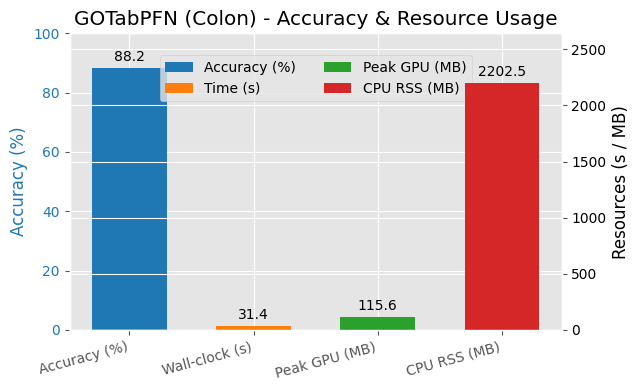

In [ ]:
# ============================================================
# GOTabPFN 5x5 CV on Colon:
#   - accuracy (mean/std)
#   - wall-clock time
#   - peak GPU memory
#   - single plot: accuracy + time + GPU + CPU RSS
# ============================================================
import os, time, psutil, random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.metrics import accuracy_score

plt.rcParams.update({"savefig.facecolor": "white", "figure.facecolor": "white"})

# ---------- Sanity: core GOTabPFN pieces must already exist ----------
required_globals = [
    "GraphFeatureOrdering",
    "PIDFSegPCA",
    "TabPFN25Head",
    "TabPFN25Config",
]
for name in required_globals:
    assert name in globals(), f"{name} is not defined. Run your GOTabPFN definition cell first."

assert "compute_deltas_adjacent_corr" in globals(), "compute_deltas_adjacent_corr not found."


# ============================================================
# 0. Generic helpers: seeding, CUDA cleanup, timing, memory
# ============================================================
def seed_everything(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)


def cleanup_cuda():
    if torch.cuda.is_available():
        try:
            torch.cuda.synchronize()
        except Exception:
            pass
        torch.cuda.empty_cache()


def run_and_measure_gpu(train_fn, *args, **kwargs):
    """
    Wrap a training/eval function:
      - clears CUDA cache
      - resets peak memory
      - times wall clock
      - returns result + time + peak GPU MB
    """
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.reset_peak_memory_stats()

    t0 = time.time()
    result = train_fn(*args, **kwargs)
    if torch.cuda.is_available():
        torch.cuda.synchronize()
    t1 = time.time()

    peak_mem_mb = None
    if torch.cuda.is_available():
        peak_bytes = torch.cuda.max_memory_allocated()
        peak_mem_mb = peak_bytes / 1024**2

    return {
        "result": result,
        "time_sec": t1 - t0,
        "gpu_peak_mb": peak_mem_mb,
    }


def get_cpu_mem_mb():
    proc = psutil.Process(os.getpid())
    return proc.memory_info().rss / 1024**2


def ensure_multiclass_contiguous(y: np.ndarray):
    """
    Map arbitrary labels to {0,1,...,C-1} in a stable way.
    Returns encoded y, label_map, num_classes.
    """
    y = np.asarray(y).reshape(-1)
    uniq = np.unique(y)
    uniq_sorted = np.sort(uniq)
    class_map = {orig: i for i, orig in enumerate(uniq_sorted.tolist())}
    y_enc = np.vectorize(class_map.get, otypes=[np.int64])(y).astype(np.int64)
    return y_enc, class_map, int(len(class_map))


# ============================================================
# 1. Dataset loader (Colon only)
# ============================================================
def prepare_dataset_for_gotabpfn(data_file: str, target_col: str, seed: int = 42):
    """
    Loads CSV, encodes labels contiguously, global standardization,
    builds 5x5 RepeatedStratifiedKFold.
    """
    df = pd.read_csv(data_file)
    assert target_col in df.columns, f"{target_col} not found in {data_file}"

    y_raw = df[target_col].to_numpy()
    X_df = df.drop(columns=[target_col])

    y_enc, class_map, num_classes = ensure_multiclass_contiguous(y_raw)

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_df.values).astype(np.float32, copy=False)

    X_all = np.asarray(X_scaled, dtype=np.float32, order="C")
    y_all = np.asarray(y_enc, dtype=np.int64)

    rkf = RepeatedStratifiedKFold(n_splits=5, n_repeats=5, random_state=seed)

    print(f"\n[DATA] {data_file}")
    print(f"  X shape       : {X_all.shape} (N={X_all.shape[0]}, m={X_all.shape[1]})")
    print(f"  #classes      : {num_classes}")
    print(f"  label mapping : {class_map}")
    return X_all, y_all, num_classes, rkf, class_map


# ============================================================
# 2. Core GOTabPFN 5x5 CV runner (dataset-agnostic)
# ============================================================
def run_gotabpfn_5x5cv_with_params(
    X_all: np.ndarray,
    y_all: np.ndarray,
    num_classes: int,
    rkf,
    params: dict,
    dataset_name: str = "",
):
    """
    One GOTabPFN + NSC + TabPFN25 5x5 CV run on (X_all, y_all)
    using a fixed hyperparameter dictionary.
    """
    seed_everything(42)

    NSC_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    TABPFN_DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
    TASK_TYPE = "binary" if num_classes == 2 else "multiclass"

    # --- Unpack params ---
    go_metric         = params["go_metric"]
    go_k              = int(params["go_num_clusters"])
    go_refine_passes  = int(params["go_refine_passes"])
    go_direction      = bool(params["go_direction_select"])
    go_feat_subsample = params.get("go_feat_subsample", None)

    if go_feat_subsample is not None:
        print(f"[WARN] go_feat_subsample={go_feat_subsample} in best_params; "
              f"this measurement run does NOT use feature subsampling explicitly.")

    nsc_seg             = params["nsc_segmentation"]
    nsc_m_rule          = params["nsc_m_rule"]
    nsc_tau             = float(params["nsc_tau"])
    nsc_gamma           = float(params["nsc_gamma"])
    nsc_beta            = float(params["nsc_beta"])
    nsc_Mmin            = int(params["nsc_Mmin"])
    nsc_Mmax            = int(params["nsc_Mmax"])
    nsc_lmin            = int(params["nsc_lmin"])
    assume_standardized = bool(params["assume_standardized"])
    tabpfn_seed         = int(params["tabpfn_seed"])

    print(f"\n[RUN] Dataset={dataset_name} | "
          f"metric={go_metric}, k={go_k}, seg={nsc_seg}, m_rule={nsc_m_rule}")

    # --- GO-LR once on full data ---
    go = GraphFeatureOrdering(
        num_clusters=go_k,
        metric=go_metric,
        refine=True,
        direction_select=go_direction,
        refine_passes=go_refine_passes,
    )

    try:
        Pi_star, _, _, _ = go.fit(X_all, seed=42, deterministic=True, use_cpu_kmeans=False)
    except RuntimeError:
        print("[GO-LR] GPU k-means failed; falling back to CPU k-means.")
        cleanup_cuda()
        Pi_star, _, _, _ = go.fit(X_all, seed=42, deterministic=True, use_cpu_kmeans=True)

    print(f"[GO-LR] Got global ordering of length {len(Pi_star)} (dataset={dataset_name}).")

    # --- TabPFN config ---
    head_cfg = TabPFN25Config(
        task_type=TASK_TYPE,
        num_classes=int(num_classes),
        device=TABPFN_DEVICE,
        random_state=tabpfn_seed,
    )

    # --- 5x5 CV ---
    accs = []
    for fold_id, (tr_idx, va_idx) in enumerate(rkf.split(X_all, y_all), start=1):
        X_tr = X_all[tr_idx]
        y_tr = y_all[tr_idx]
        X_va = X_all[va_idx]
        y_va = y_all[va_idx]

        # NSC instance per fold
        nsc = PIDFSegPCA(
            segmentation=nsc_seg,
            l_min=nsc_lmin,
            m_rule=nsc_m_rule,
            gamma=nsc_gamma,
            beta=nsc_beta,
            tau=nsc_tau,
            M_min=nsc_Mmin,
            M_max=nsc_Mmax,
            assume_standardized=assume_standardized,
            device=NSC_DEVICE,
        )

        deltas = None
        if nsc_seg != "uniform":
            deltas = compute_deltas_adjacent_corr(X_tr, Pi_star)

        X_tr_t = torch.from_numpy(X_tr)
        nsc.configure(Pi_star=Pi_star, X_train=X_tr_t, tau=nsc_tau, deltas=deltas)

        Z_tr = nsc.compress(X_tr_t, mode="flatten").cpu().numpy()
        Z_va = nsc.compress(torch.from_numpy(X_va), mode="flatten").cpu().numpy()

        head = TabPFN25Head(head_cfg)
        head.fit(Z_tr, y_tr)

        P = head.predict_proba(Z_va)
        pred = np.argmax(P, axis=1)
        acc = float(accuracy_score(y_va, pred))
        accs.append(acc)

        print(f"[{dataset_name}] Fold {fold_id:2d}/25  acc = {acc*100:.2f}%")

        cleanup_cuda()

    mean_acc = float(np.mean(accs))
    std_acc  = float(np.std(accs, ddof=1)) if len(accs) > 1 else 0.0

    print(f"\n[RESULT] {dataset_name} 5x5 CV summary:")
    print(f"  mean_acc = {mean_acc*100:.2f}%")
    print(f"  std_acc  = {std_acc*100:.2f}%")
    return {
        "mean_acc": mean_acc,
        "std_acc": std_acc,
        "fold_accs": accs,
    }


# ============================================================
# 3. Colon config + best hyperparameters
# ============================================================
COLON_CONFIG = {
    "file": "coloncancer_encoded.csv",
    "target": "label",
    "best_params": {
        "go_metric": "euclidean",
        "go_num_clusters": 10,
        "go_refine_passes": 3,
        "go_direction_select": True,
        "nsc_segmentation": "equal_mass",
        "nsc_m_rule": "idf",
        "nsc_tau": 0.99,
        "nsc_gamma": 1.7570143129240916,
        "nsc_beta": 0.2244046472232107,
        "nsc_Mmin": 64,
        "nsc_Mmax": 384,
        "nsc_lmin": 16,
        "assume_standardized": False,
        "tabpfn_seed": 42,
    },
}


# ============================================================
# 4. Run Colon + print performance & resource usage
# ============================================================
print("\n" + "=" * 70)
print("Running GOTabPFN diagnostics for dataset: Colon")
print("=" * 70)

X_all, y_all, num_classes, rkf, class_map = prepare_dataset_for_gotabpfn(
    COLON_CONFIG["file"], COLON_CONFIG["target"], seed=42
)

def _train_once():
    return run_gotabpfn_5x5cv_with_params(
        X_all=X_all,
        y_all=y_all,
        num_classes=num_classes,
        rkf=rkf,
        params=COLON_CONFIG["best_params"],
        dataset_name="Colon",
    )

stats = run_and_measure_gpu(_train_once)
res = stats["result"]

mean_acc = res["mean_acc"] * 100.0
std_acc  = res["std_acc"] * 100.0
n_folds  = len(res["fold_accs"])
time_sec = stats["time_sec"]
gpu_peak = stats["gpu_peak_mb"]
cpu_rss  = get_cpu_mem_mb()

print("\n================ Performance & Resource Usage ================")
print(f"Mean CV accuracy : {mean_acc:.2f}%")
print(f"Std CV accuracy  : {std_acc:.2f}%")
print(f"Num folds        : {n_folds}")
print()
print(f"Wall-clock time  : {time_sec:.2f} seconds")
if gpu_peak is not None:
    print(f"Peak GPU memory  : {gpu_peak:.1f} MB")
else:
    print("Peak GPU memory  : (no CUDA detected)")
print(f"Current CPU RSS  : {cpu_rss:.1f} MB")
print("==============================================================")

# ============================================================
# 5. Single plot: Accuracy + time + GPU + CPU RSS
# ============================================================
metrics = ["Accuracy (%)", "Wall-clock (s)", "Peak GPU (MB)", "CPU RSS (MB)"]
x = np.arange(len(metrics))

fig, ax1 = plt.subplots(figsize=(6.5, 4.0))

# --- Left axis: accuracy bar (blue) ---
acc_bar = ax1.bar(
    x[0],
    mean_acc,
    width=0.6,
    color="tab:blue",
    label="Accuracy (%)",
)
ax1.set_ylabel("Accuracy (%)", color="tab:blue")
ax1.tick_params(axis="y", labelcolor="tab:blue")
ax1.set_ylim(0, max(100.0, mean_acc * 1.1))

# --- Right axis: resource metrics (each with its own color) ---
ax2 = ax1.twinx()

gpu_val = gpu_peak if gpu_peak is not None else 0.0
resources = [time_sec, gpu_val, cpu_rss]
res_max = max(resources) if len(resources) > 0 else 1.0

bar_time = ax2.bar(
    x[1],
    time_sec,
    width=0.6,
    color="tab:orange",
    label="Time (s)",
)
bar_gpu = ax2.bar(
    x[2],
    gpu_val,
    width=0.6,
    color="tab:green",
    label="Peak GPU (MB)",
)
bar_cpu = ax2.bar(
    x[3],
    cpu_rss,
    width=0.6,
    color="tab:red",
    label="CPU RSS (MB)",
)

ax2.set_ylabel("Resources (s / MB)", color="black")
ax2.tick_params(axis="y", labelcolor="black")
ax2.set_ylim(0, res_max * 1.2)

# X ticks + labels
ax1.set_xticks(x)
ax1.set_xticklabels(metrics, rotation=15, ha="right")

# Annotate bar values
ax1.bar_label(acc_bar, fmt="%.1f", padding=3)
ax2.bar_label(bar_time, fmt="%.1f", padding=3)
ax2.bar_label(bar_gpu, fmt="%.1f", padding=3)
ax2.bar_label(bar_cpu, fmt="%.1f", padding=3)

# Legend: combine handles from both axes and place at top middle
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(
    handles1 + handles2,
    labels1 + labels2,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.95),
    ncol=2,
)

plt.title("GOTabPFN (Colon) - Accuracy & Resource Usage")
plt.tight_layout()
plt.savefig("gotabpfn_colon_perf_resource.png", dpi=600, bbox_inches="tight")
plt.show()